# Task 4: Finding Visually Similar Fashion Items

Given a photograph of a fashion item, return the Top-K most visually similar products from the
~38,600-item catalogue.

## Approach

Retrieval has no fixed label set, so there is nothing to classify. Instead the system learns an
**embedding**: a convolutional network that turns any image into 128 numbers, arranged so that
distance in that space means visual similarity. Searching is then just ranking by cosine
similarity against the catalogue's stored vectors.

The network is a CNN - four convolutional blocks, widths 32 → 64 → 128 → 256, global average
pooling, then a linear projection to 128 dimensions. It is trained **supervised**, with a
batch-hard triplet loss: `articleType` decides which pairs should be close and which should be
far, and two auxiliary heads predict the type and the colour outright. Those heads are discarded
at inference. Task 4 runs at **120×160**.

## The question this notebook is really about

Every one of the catalogue's photographs is a centred, studio-lit garment on white. A photograph
a user takes is none of those things. **Part 6 measures what that uniformity costs** by training
the same network twice - once on the catalogue exactly as it ships, once with real photographic
backdrops composited behind the clothes - and grading both on catalogue images, on synthetic
backdrops, and on 31 genuine uploads.

## How the notebook is organised

| Part | What it covers |
|---|---|
| 1-3 | Setup, the gallery, and how retrieval is scored |
| 4-5 | The search engine and the encoder that drives it |
| 6 | What the state of the data does to the result - the 2×2 |
| 7 | Results, and whether the embedding space is organised |
| 8 | Real uploads: both encoders on 31 genuine photographs |
| 9-10 | Saving the index, and the summary |


## Part 1: Setup and configuration

In [5]:
# ============================================
# CELL 1 - Imports, device and reproducibility
# ============================================

import os
import re
import json
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

PyTorch: 2.11.0+cu128
Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU


In [6]:
# ============================================
# CELL 2 - Paths
# ============================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

# The project root has to be importable before any `from src...` line runs, and
# the first one is two cells below. Relying on the editor to put the workspace
# root on the path works until it does not, and then the notebook fails with
# `ModuleNotFoundError: No module named 'src'` a long way from the cause.
import sys
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

DATASET_ROOT = PROJECT_DIR / "A2_FashionDataset"
DATASET_DIR = DATASET_ROOT / "FashionDataset"

TEST_IMAGE_DIR = DATASET_DIR / "test" / "images_test"
USER_IMAGE_DIR = DATASET_ROOT / "input_images"

PROCESSED_DIR = DATASET_ROOT / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task4"
TRAINED_DIR = PROJECT_DIR / "artifacts" / "task4_120x160"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# The catalogue at 120x160, and the item masks that let a garment be cut out and
# pasted onto a different backdrop. Both are written by
# `scripts/build_task4_cache.py --resolution 120x160`.
GALLERY_CSV = PROCESSED_DIR / "task4_gallery_120x160.csv"
CACHE_X = PROCESSED_DIR / "task4_cache_120x160.npy"
CACHE_MASKS = PROCESSED_DIR / "task4_masks_120x160.npy"
IMAGE_DIR = PROCESSED_DIR / "images_train_120x160"
PREDICTION_METADATA = PROCESSED_DIR / "prediction_metadata.csv"

for required in (GALLERY_CSV, CACHE_X, CACHE_MASKS):
    assert required.exists(), (
        f"Missing {required.name}. Run:\n"
        "    python scripts/build_task4_cache.py --resolution 120x160")

print("Processed directory:", PROCESSED_DIR)
print("Artifact directory :", ARTIFACT_DIR)
print("Trained encoder dir:", TRAINED_DIR)


Processed directory: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed
Artifact directory : c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task4
Trained encoder dir: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task4_120x160


In [7]:
# ============================================
# CELL 3 - Configuration
# ============================================

CONFIG = {
    # --- image ---
    "image_width": 120,         # the re-exported catalogue, not an upscale
    "image_height": 160,


    # --- retrieval ---
    "top_k": 10,                 # K for the headline metrics
    "k_values": [1, 5, 10, 20],  # K values reported in the tables
    "embedding_dim": 128,        # bottleneck size for the learned encoders

    # --- evaluation ---
    "n_queries": 2000,           # sampled query set; raise for tighter estimates
    "relevance": "articleType",  # a hit shares this attribute with the query
    # Secondary attribute the Triplet model was NOT trained on. Evaluating on it
    # removes the structural advantage that method has under `relevance`, because
    # it was optimised for exactly that attribute.
    "relevance_control": "baseColour",
    # Random sampling is dominated by common classes (Watches contributed 103 of
    # 2000 queries in RUN 1, while several types contributed one). Stratified
    # sampling caps the contribution of any single class so rare types are measured.
    "stratified_queries": True,
    "max_queries_per_class": 40,

    # --- realistic-use-case protocol (Part 4c) ---
    # The deployed system receives a photo that is NOT in the catalogue. Holding
    # out whole PRODUCTS (not rows) gives queries the encoders have never seen,
    # and simultaneously removes the duplicate-photo problem for free.
    "holdout_fraction": 0.15,

    # --- improvements evaluated in Part 4c ---
    "aug_flip": True,            # horizontal flip during training
    "aug_photometric": 0.15,     # +-15% brightness/contrast jitter; 0 disables
    "aux_type_weight": 0.5,      # auxiliary articleType classification loss
    "aux_colour_weight": 0.5,    # auxiliary baseColour loss - keeps colour in the embedding
    "use_tta": True,             # average the embedding of the image and its mirror
    "rerank_alpha": 0.8,         # embedding vs colour weight when re-ranking

    # --- training ---
    "batch_size": 128,
    "triplet_epochs": 30,        # the encoder below; all three losses still falling at 12
    "learning_rate": 1e-3,
    "triplet_margin": 0.3,
    "num_workers": 0,            # keep 0 on Windows/Jupyter
}

IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)

print(json.dumps(CONFIG, indent=2))

{
  "image_width": 120,
  "image_height": 160,
  "top_k": 10,
  "k_values": [
    1,
    5,
    10,
    20
  ],
  "embedding_dim": 128,
  "n_queries": 2000,
  "relevance": "articleType",
  "relevance_control": "baseColour",
  "stratified_queries": true,
  "max_queries_per_class": 40,
  "holdout_fraction": 0.15,
  "aug_flip": true,
  "aug_photometric": 0.15,
  "aux_type_weight": 0.5,
  "aux_colour_weight": 0.5,
  "use_tta": true,
  "rerank_alpha": 0.8,
  "batch_size": 128,
  "triplet_epochs": 30,
  "learning_rate": 0.001,
  "triplet_margin": 0.3,
  "num_workers": 0
}


## Part 2: The gallery

The gallery is every training image with usable metadata - the same cleaned file the other
notebooks consume. Unlike Task 3, **no rows are dropped for rare labels**: retrieval has no
class imbalance problem, and a rare item should still be findable.

In [8]:
# ============================================
# CELL 4 - Load the gallery metadata
# ============================================

# 38,571 rows, not 38,612: the pipeline marks 41 images `use_for_supervised =
# False` because duplicate photographs of the same product carry conflicting
# labels, and Task 4 drops them. Forty-one rows sounds immaterial and is not -
# the holdout is drawn by shuffling PRODUCTS, so removing any row reshuffles the
# whole split. Numbers measured on the old gallery are not comparable with these.
gallery = pd.read_csv(GALLERY_CSV).reset_index(drop=True)
gallery["position"] = np.arange(len(gallery))     # row index == embedding row index
gallery["image_path"] = [str(IMAGE_DIR / f"{i}.jpg") for i in gallery["id"]]

print("Gallery size:", len(gallery))
print("Distinct articleType :", gallery["articleType"].nunique())
print("Distinct subCategory :", gallery["subCategory"].nunique())
print("Distinct baseColour  :", gallery["baseColour"].nunique())

display(gallery[["id", "articleType", "subCategory", "masterCategory",
                 "baseColour", "gender", "productDisplayName"]].head())

print("\nMost common articleTypes:")
display(gallery["articleType"].value_counts().head(10).to_frame("Count"))


Gallery size: 38571
Distinct articleType : 124
Distinct subCategory : 41
Distinct baseColour  : 46


,id,articleType,subCategory,masterCategory,baseColour,gender,productDisplayName
0,1163,Tshirts,Topwear,Apparel,Blue,Men,Nike Sahara Team India Fanwear Round Neck Jersey
1,1164,Tshirts,Topwear,Apparel,Blue,Men,Nike Men Blue T20 Indian Cricket Jersey
2,1525,Backpacks,Bags,Accessories,Navy Blue,Unisex,Puma Deck Navy Blue Backpack
3,1526,Backpacks,Bags,Accessories,Black,Unisex,Puma Big Cat Backpack Black
4,1528,Jackets,Topwear,Apparel,Black,Men,Puma Men Ferrari Black Fleece Jacket



Most common articleTypes:


,Count
articleType,
Tshirts,6773
Shirts,3083
Casual Shoes,2680
Watches,2249
Sports Shoes,1991
Tops,1613
Kurtas,1556
Handbags,1439
Heels,1048


In [9]:
# ============================================
# CELL 5 - Image cache and item masks
# ============================================

def load_image_array(path, size=IMAGE_SIZE_PIL):
    """Single source of truth for reading one image (gallery and queries alike)."""
    with Image.open(path) as img:
        img = img.convert("RGB").resize(size, Image.BILINEAR)
        return np.asarray(img, dtype=np.uint8)


IMAGES = np.load(CACHE_X, mmap_mode="r")
ITEM_MASKS = np.load(CACHE_MASKS, mmap_mode="r")
assert len(IMAGES) == len(ITEM_MASKS) == len(gallery), "cache and gallery disagree"
print("Image cache:", IMAGES.shape, IMAGES.dtype)
print("Item masks :", ITEM_MASKS.shape, "mean occupancy",
      round(float(np.asarray(ITEM_MASKS[:2000]).mean()), 3))

# alignment check against the source file on disk
probe = gallery.sample(1, random_state=RANDOM_STATE).iloc[0]
assert np.array_equal(np.asarray(IMAGES[probe["position"]]),
                      load_image_array(probe["image_path"])), "Cache is misaligned"
print("Cache alignment verified. Memory footprint:",
      round(IMAGES.nbytes / 1e6, 1), "MB")


Image cache: (38571, 160, 120, 3) uint8
Item masks : (38571, 160, 120) mean occupancy 0.348
Cache alignment verified. Memory footprint: 2221.7 MB


## Part 3: How retrieval is scored

Defined **before** any method is built, so no method can be tuned against a metric invented
afterwards.

**Relevance.** A retrieved item is a hit if it shares the query's `articleType`.

**Metrics.**

* **Precision@K** - of the K returned items, what fraction are relevant. The number a user
  experiences directly.
* **Recall@K** - of all relevant items in the gallery, what fraction appeared in the top K.
  Low by construction when a class has thousands of members, so it is read as a trend.
* **mAP@K** - mean average precision; rewards putting the relevant items *earlier*.
* **nDCG@K** - uses graded relevance (same `articleType` = 1.0, same `subCategory` = 0.5,
  same `masterCategory` = 0.25) so a near-miss scores better than a nonsense result.

**Random baseline.** Retrieving K items at random gives a Precision@K equal to the class's
share of the gallery. Every method is compared against that floor.

In [10]:
# ============================================
# CELL 6 - Relevance definitions
# ============================================

# The split, the query sampler and every retrieval metric now live in
# src/evaluation/metrics.py. They used to be defined here and again, separately,
# in the background-augmentation notebook. The two copies agreed on the split but
# not on what they measured - only this one reports graded relevance, nDCG
# against an achievable ideal, and R-precision - and nothing stopped them drifting
# further apart on any edit. One definition, imported by both notebooks, is what
# makes their numbers comparable at all.
from src.evaluation.metrics import RetrievalProtocol

RELEVANCE_COL = CONFIG["relevance"]

PROTOCOL = RetrievalProtocol(
    gallery,
    relevance=CONFIG["relevance"],
    control=CONFIG["relevance_control"],
    holdout_fraction=CONFIG["holdout_fraction"],
    n_queries=CONFIG["n_queries"],
    stratified=CONFIG["stratified_queries"],
    max_queries_per_class=CONFIG["max_queries_per_class"],
    top_k=CONFIG["top_k"],
    k_values=tuple(CONFIG["k_values"]),
    seed=RANDOM_STATE,
)

# Local names kept so the rest of the notebook reads unchanged.
article = PROTOCOL.article
subcat = PROTOCOL.subcat
mastercat = PROTOCOL.mastercat
product_name = PROTOCOL.product_name

binary_relevance = PROTOCOL.binary_relevance
graded_relevance = PROTOCOL.graded_relevance

class_counts = PROTOCOL.class_counts
relevant_total = PROTOCOL.relevant_total
subcat_total = PROTOCOL.subcat_total
master_total = PROTOCOL.master_total

print(f"Relevance attribute: {RELEVANCE_COL}")
print(f"Classes: {len(class_counts)}")
print(f"Largest: {class_counts.index[0]} ({class_counts.iloc[0]} items, "
      f"{class_counts.iloc[0] / len(gallery) * 100:.1f}% of the gallery)")
print(f"Smallest: {class_counts.index[-1]} ({class_counts.iloc[-1]} items)")
print(f"\nRandom-retrieval Precision@K floor (weighted by class size): "
      f"{(class_counts / len(gallery) * class_counts).sum() / len(gallery) * 100:.2f}%")


Relevance attribute: articleType
Classes: 124
Largest: Tshirts (6773 items, 17.6% of the gallery)
Smallest: Lounge Tshirts (1 items)

Random-retrieval Precision@K floor (weighted by class size): 5.91%


In [11]:
# ============================================
# CELL 7 - Retrieval metrics
# ============================================

# Imported rather than redefined - see CELL 6. The definitions themselves, and
# the reasoning behind them, are in src/evaluation/metrics.py.
dcg = PROTOCOL._dcg
ideal_gains = PROTOCOL._ideal_gains
evaluate_ranking = PROTOCOL.evaluate_ranking

print("Metric functions bound from src/evaluation/metrics.py:")
print("  P@K         - precision at K")
print("  R@K         - recall at K (reported, but see the caveat below)")
print("  AP@K        - average precision, normalised by the achievable hit count")
print("  nDCG@K      - graded relevance against the BEST ACHIEVABLE ranking")
print("  R-precision - precision at K = number of relevant items")
print()
print("CAVEAT on Recall@K: with 6,781 Tshirts in the gallery, ten results can")
print("recover at most 0.15% of them, so R@10 is near-zero by construction and")
print("is not comparable across classes. R-precision is the size-invariant")
print("alternative and should be preferred in the report.")


Metric functions bound from src/evaluation/metrics.py:
  P@K         - precision at K
  R@K         - recall at K (reported, but see the caveat below)
  AP@K        - average precision, normalised by the achievable hit count
  nDCG@K      - graded relevance against the BEST ACHIEVABLE ranking
  R-precision - precision at K = number of relevant items

CAVEAT on Recall@K: with 6,781 Tshirts in the gallery, ten results can
recover at most 0.15% of them, so R@10 is near-zero by construction and
is not comparable across classes. R-precision is the size-invariant
alternative and should be preferred in the report.


## Part 4: The search engine

Embeddings are L2-normalised, which makes the cosine similarity between two vectors a single
dot product. Similarity against the whole gallery is then one matrix multiplication.

At 38,600 × 128 floats the entire index is under 20 MB, so an **exact** search is fast enough
(tens of milliseconds per query on GPU) and there is no need for an approximate index such as
FAISS. Exact search also means the reported metrics reflect the embedding quality rather than
an index's approximation error.

In [12]:
# ============================================
# CELL 8 - Search index
# ============================================

# Exact cosine search over a matrix of embeddings. Defined in
# src/evaluation/metrics.py so the notebooks and the offline evaluation share it.
from src.evaluation.metrics import VisualSearchIndex

print("VisualSearchIndex ready.")


VisualSearchIndex ready.


In [13]:
# ============================================
# CELL 9 - Query set and exclusion lists
# ============================================

# Built by the protocol. Stratified sampling caps the number of queries drawn
# from any one class, so the headline is not dominated by whichever types happen
# to be most common - random sampling once gave Watches 103 of 2000 queries.
query_positions = PROTOCOL.query_positions

# Standard mode: a query must not retrieve itself.
# Strict mode: also suppress every other photo of the SAME product.
exclude_standard = PROTOCOL.exclude_standard
exclude_strict = PROTOCOL.exclude_strict

if CONFIG["stratified_queries"]:
    print(f"Stratified query set: {len(query_positions)} queries, "
          f"max {CONFIG['max_queries_per_class']} per class")
else:
    print(f"Random query set: {len(query_positions)} queries")

query_class_counts = pd.Series(article[query_positions]).value_counts()
print(f"Classes represented: {len(query_class_counts)} of {len(class_counts)}")
print(f"Queries per class - min {query_class_counts.min()}, "
      f"median {int(query_class_counts.median())}, max {query_class_counts.max()}")

duplicates_removed = np.array([len(e) - 1 for e in exclude_strict])
print(f"\nStrict mode additionally suppresses {duplicates_removed.mean():.1f} items per "
      f"query on average (max {duplicates_removed.max()})")
print(f"Queries with at least one duplicate photo: "
      f"{(duplicates_removed > 0).mean() * 100:.1f}%")


Stratified query set: 2000 queries, max 40 per class
Classes represented: 123 of 124
Queries per class - min 1, median 20, max 31

Strict mode additionally suppresses 3.0 items per query on average (max 81)
Queries with at least one duplicate photo: 37.9%


In [14]:
# ============================================
# CELL 10 - Evaluation harness
# ============================================

RESULTS = {}
INDEXES = {}
EMBEDDINGS = {}


def evaluate_index(index, mode="standard", k_values=None, store=True):
    """Run every query through `index` and average the metrics.

    Thin wrapper over PROTOCOL.evaluate_index so the results dictionary stays
    local to this notebook while the metrics stay shared.
    """
    summary, ranked = PROTOCOL.evaluate_index(index, index.vectors, mode=mode,
                                              k_values=k_values, store=False)
    if store:
        RESULTS.setdefault(index.name, {})[mode] = summary
    return summary, ranked


def results_table(mode="standard", k=None):
    """Presentation only - the metrics behind it come from the protocol."""
    k = k or CONFIG["top_k"]
    rows = []
    for name, modes in RESULTS.items():
        if mode not in modes:
            continue
        s = modes[mode]
        rows.append({
            "Method": name,
            "Dim": int(s["dim"]),
            "P@1": round(s["P@1"] * 100, 2),
            f"P@{k}": round(s[f"P@{k}"] * 100, 2),
            f"mAP@{k}": round(s[f"AP@{k}"] * 100, 2),
            f"nDCG@{k}": round(s[f"nDCG@{k}"] * 100, 2),
            "R-prec": round(s["R-precision"] * 100, 2),
            "ms/query": round(s["ms_per_query"], 2),
        })
    return pd.DataFrame(rows).sort_values(f"P@{k}", ascending=False)


print("Evaluation harness ready.")


Evaluation harness ready.


### Part 4b: Shared components

One dataset class, one set of normalisation statistics and one embedding-extraction function,
so nothing downstream differs by data handling. `colour_histogram` is a hand-built colour
representation, retained because the fusion and re-ranking experiments need a view of colour
that owes nothing to the encoder.

In [15]:
# ============================================
# CELL 13 - Dataset, normalisation and extraction helper
# ============================================

# Statistics computed once over the gallery, reused by every learned method.
_sample = np.asarray(IMAGES[np.sort(np.random.choice(len(gallery), 4000, replace=False))],
                     dtype=np.float32) / 255.0
CHANNEL_MEAN = _sample.mean(axis=(0, 1, 2))
CHANNEL_STD = _sample.std(axis=(0, 1, 2))
del _sample
print("Channel mean:", CHANNEL_MEAN.round(4), "| std:", CHANNEL_STD.round(4))

MEAN_T = torch.tensor(CHANNEL_MEAN, dtype=torch.float32).view(1, 3, 1, 1)
STD_T = torch.tensor(CHANNEL_STD, dtype=torch.float32).view(1, 3, 1, 1)


class GalleryDataset(Dataset):
    """Serves normalised image tensors, optionally with a class label."""

    def __init__(self, images, positions, labels=None):
        self.images = images
        self.positions = np.asarray(positions)
        self.labels = None if labels is None else np.asarray(labels)

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        position = self.positions[index]
        array = np.asarray(self.images[position], dtype=np.float32) / 255.0
        tensor = torch.from_numpy(array.transpose(2, 0, 1))
        tensor = (tensor - MEAN_T[0]) / STD_T[0]
        if self.labels is None:
            return tensor, int(position)
        return tensor, int(self.labels[index])


def make_gallery_loader(positions=None, labels=None, batch_size=None, shuffle=False):
    positions = np.arange(len(gallery)) if positions is None else positions
    return DataLoader(
        GalleryDataset(IMAGES, positions, labels),
        batch_size=batch_size or CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        pin_memory=(DEVICE.type == "cuda"),
    )


@torch.no_grad()
def extract_embeddings(encoder, positions=None, batch_size=256):
    """Run `encoder` over the gallery (or a subset) and return a numpy matrix."""
    encoder.eval()
    positions = np.arange(len(gallery)) if positions is None else positions
    loader = make_gallery_loader(positions, batch_size=batch_size)

    out = []
    for images, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        vectors = encoder(images)
        out.append(vectors.float().cpu().numpy())
    return np.vstack(out)


print("Shared components ready.")

Channel mean: [0.2185 0.2185 0.2185] | std: [0.4674 0.4674 0.4674]
Shared components ready.


In [16]:
# ============================================
# CELL 13b - Colour histogram
# ============================================

# A 128-bin HSV histogram, built directly from pixels. Kept because the
# fusion and re-ranking experiments need a colour representation that owes
# nothing to the encoder; the gradient half of that descriptor is not kept.
#
# HSV rather than RGB: it separates hue from brightness, so a navy shirt in
# shadow and the same shirt in light land in the same hue bins.


def rgb_to_hsv_array(rgb):
    """Vectorised RGB->HSV for a batch of uint8 images (N, H, W, 3)."""
    arr = rgb.astype(np.float32) / 255.0
    maxc = arr.max(axis=-1)
    minc = arr.min(axis=-1)
    delta = maxc - minc

    hue = np.zeros_like(maxc)
    mask = delta > 1e-6
    r, g, b = arr[..., 0], arr[..., 1], arr[..., 2]

    idx = mask & (maxc == r)
    hue[idx] = ((g[idx] - b[idx]) / delta[idx]) % 6
    idx = mask & (maxc == g)
    hue[idx] = ((b[idx] - r[idx]) / delta[idx]) + 2
    idx = mask & (maxc == b)
    hue[idx] = ((r[idx] - g[idx]) / delta[idx]) + 4

    hue = hue / 6.0
    saturation = np.where(maxc > 1e-6, delta / np.clip(maxc, 1e-6, None), 0.0)
    return hue, saturation, maxc


def colour_histogram(batch, hue_bins=8, sat_bins=4, val_bins=4):
    """Normalised HSV histogram, 8 x 4 x 4 = 128 bins per image."""
    n = len(batch)
    hue, saturation, value = rgb_to_hsv_array(batch)
    h_idx = np.clip((hue * hue_bins).astype(int), 0, hue_bins - 1)
    s_idx = np.clip((saturation * sat_bins).astype(int), 0, sat_bins - 1)
    v_idx = np.clip((value * val_bins).astype(int), 0, val_bins - 1)
    flat = (h_idx * sat_bins * val_bins + s_idx * val_bins + v_idx).reshape(n, -1)

    n_bins = hue_bins * sat_bins * val_bins
    histogram = np.zeros((n, n_bins), dtype=np.float32)
    for i in range(n):
        histogram[i] = np.bincount(flat[i], minlength=n_bins)
    histogram /= np.clip(histogram.sum(axis=1, keepdims=True), 1e-8, None)
    return histogram


def gallery_colour_histogram(batch_size=2048):
    """The histogram for every gallery image, built once."""
    blocks = []
    for start in range(0, len(gallery), batch_size):
        blocks.append(colour_histogram(
            np.asarray(IMAGES[start:start + batch_size])))
    return np.vstack(blocks)


COLOUR_HIST = gallery_colour_histogram()
print("Colour histograms:", COLOUR_HIST.shape)


Colour histograms: (38571, 128)


In [17]:
# ============================================
# CELL 13c - Building blocks for the encoder
# ============================================

# ConvBlock, the P x K batch sampler and the batch-hard triplet loss. All three
# were first written for methods this notebook no longer builds, and all three
# are what the surviving encoder is made of, so they live here rather than
# inside any one method.

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class PKSampler(torch.utils.data.Sampler):
    """Yields batches of P classes x K images, avoiding duplicates of one product."""

    def __init__(self, labels, product_ids, p=16, k=8, batches_per_epoch=200, seed=RANDOM_STATE):
        self.p, self.k = p, k
        self.batches_per_epoch = batches_per_epoch
        self.rng = np.random.default_rng(seed)

        self.by_class = defaultdict(list)
        for index, label in enumerate(labels):
            self.by_class[label].append(index)
        # only classes with enough images to fill K slots
        self.classes = [c for c, items in self.by_class.items() if len(items) >= k]
        self.product_ids = np.asarray(product_ids)

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            batch = []
            chosen = self.rng.choice(self.classes, size=min(self.p, len(self.classes)),
                                     replace=False)
            for cls in chosen:
                candidates = self.by_class[cls]
                picked, used_products = [], set()
                for index in self.rng.permutation(candidates):
                    product = self.product_ids[index]
                    if product in used_products:
                        continue          # skip duplicate photos of the same product
                    picked.append(index)
                    used_products.add(product)
                    if len(picked) == self.k:
                        break
                while len(picked) < self.k:   # fall back if the class is thin
                    picked.append(int(self.rng.choice(candidates)))
                batch.extend(picked)
            yield batch


def batch_hard_triplet_loss(embeddings, labels, margin=0.3):
    """Hardest positive and hardest negative per anchor, within the batch."""
    distances = torch.cdist(embeddings, embeddings, p=2)
    same = labels[:, None] == labels[None, :]
    eye = torch.eye(len(labels), dtype=torch.bool, device=labels.device)

    positive_mask = same & ~eye
    negative_mask = ~same

    hardest_positive = (distances * positive_mask).max(dim=1).values
    masked = distances + (~negative_mask).float() * 1e6
    hardest_negative = masked.min(dim=1).values

    valid = positive_mask.any(dim=1) & negative_mask.any(dim=1)
    loss = F.relu(hardest_positive - hardest_negative + margin)
    return loss[valid].mean() if valid.any() else loss.sum() * 0.0


print("Encoder building blocks ready.")


Encoder building blocks ready.


### Part 4c: Rebuilding for the real use case

Everything above shares a flaw that only matters once the deployment scenario is stated
plainly: **a user uploads a photograph that is not in the catalogue, and the system returns
similar catalogue items.**

Two problems with the protocol so far:

1. **The encoder was trained on the entire gallery**, and the queries were drawn from that
   same gallery. Every query image was part of training. That is the retrieval equivalent of
   testing on the training set, and any learned model is flattered by it.
2. **A triplet loss on `articleType` alone discards colour.** Nothing in that objective ever
   asks about it, so the embedding is free to throw it away. A shopper asking for "something
   like this" cares about colour, which is why the encoder carries an auxiliary `baseColour`
   head as well as a type head.

This section fixes both, then measures whether the fixes help.

**New protocol.** Whole *products* are held out (not rows), so no photograph of a held-out
product appears anywhere in training or in the catalogue index. Held-out images act as the
"user upload"; the catalogue is the remaining items. Grouping by product also removes the
duplicate-photo issue entirely - there is no strict/standard distinction left to make.

**Four changes tested, each measurable:**

| Change | Intended effect |
|---|---|
| Train on the catalogue split only | honest measurement, no leakage |
| Auxiliary colour + type classification losses | keep colour in the embedding |
| Flip and photometric augmentation | robustness to a user's photo |
| Test-time augmentation, fusion, colour re-ranking | cheap gains at query time |

In [18]:
# ============================================
# CELL 24d - Product-level held-out split
# ============================================

# Grouped by product so every photograph of a held-out item is held out
# together, and asserted leak-free inside the protocol.
product_key = PROTOCOL.product_key
CATALOGUE_POS = PROTOCOL.catalogue_pos     # searchable catalogue + training data
HELDOUT_POS = PROTOCOL.heldout_pos         # stand-ins for "user uploads"
HELDOUT_QUERIES = PROTOCOL.heldout_queries

print(f"Products: {len(np.unique(product_key))} -> "
      f"{int(len(np.unique(product_key)) * CONFIG['holdout_fraction'])} held out")
print(f"Catalogue (index + training): {len(CATALOGUE_POS):,} images")
print(f"Held-out images whose type exists in the catalogue: {len(HELDOUT_POS):,}")
print(f"Query set for this section: {len(HELDOUT_QUERIES):,} unseen images")

assert not (set(product_key[CATALOGUE_POS]) & set(product_key[HELDOUT_POS])), \
    "Product leaked across the split"


Products: 27527 -> 4129 held out
Catalogue (index + training): 32,944 images
Held-out images whose type exists in the catalogue: 5,626
Query set for this section: 2,000 unseen images


In [19]:
# ============================================
# CELL 24e - Catalogue-only index and the deployment metric
# ============================================

from src.evaluation.metrics import CatalogueIndex as _CatalogueIndex

colour_values = PROTOCOL.colour

DEPLOY_RESULTS = {}


def CatalogueIndex(embeddings, name="index", catalogue=None):
    """Searches only the catalogue split and returns GALLERY positions.

    Wrapper that injects PROTOCOL, so call sites in this notebook stay unchanged.
    """
    return _CatalogueIndex(embeddings, PROTOCOL, name=name, catalogue=catalogue)


def evaluate_deployment(index, embeddings, queries=None, k_values=None, label=None):
    """Evaluate with unseen queries against the catalogue index.

    A result is useful when the TYPE and the COLOUR match, which is much closer
    to what "similar item" means to a shopper than articleType alone.
    """
    summary, ranked = PROTOCOL.evaluate_deployment(
        index, embeddings, queries=queries, k_values=k_values,
        label=label, store=False)
    DEPLOY_RESULTS[label or index.name] = summary
    return summary, ranked


def deployment_table():
    return PROTOCOL.deployment_table(DEPLOY_RESULTS)


# The colour histogram is the one non-learned representation still built, so it
# is the reference the encoder has to beat: a floor set by measuring colour
# directly from pixels, with nothing learned.
EMBEDDINGS["Colour histogram"] = COLOUR_HIST
INDEXES["Colour histogram"] = CatalogueIndex(COLOUR_HIST, name="Colour histogram")
evaluate_deployment(INDEXES["Colour histogram"], COLOUR_HIST,
                    label="Colour histogram")

print("Reference point - unseen queries against the catalogue:")
display(deployment_table())
print("Every model below is trained on the catalogue split only, so no held-out")
print("product appears in any training set.")


Reference point - unseen queries against the catalogue:


,Method,Dim,P@1,P@10,mAP@10,nDCG@10,colour@10,both@10,ms/query
0,Colour histogram,128,39.5,28.67,20.59,45.69,47.68,15.92,0.06


Every model below is trained on the catalogue split only, so no held-out
product appears in any training set.


## Part 5: The encoder

`ImprovedEncoder` is the four-block convolutional backbone with a 128-dimensional
projection, plus two auxiliary heads - one for `articleType`, one for
`baseColour` - that are used only for training and dropped at inference. The
auxiliary colour head is what separates this encoder from a plain triplet
network: a triplet loss on `articleType` alone produces an embedding that ranks
item type well and colour barely at all.

### Trained by a script, not by this cell

A 42-epoch run at 120x160 takes about 100 minutes, which is longer than a
notebook kernel should be asked to survive, and every epoch is checkpointed so a
killed run can resume. Training therefore lives in
`src/training/train_task4_120x160.py`:

```
python scripts/build_task4_cache.py --resolution 120x160
python -m src.training.train_task4_120x160 --backgrounds mixed --seed 42
```

The cells below load what that run produced.

### Two collapses, and the recipe that avoids them

Training this encoder from scratch with the augmentation switched on from epoch 1
**collapses**: the triplet loss sits at exactly the margin (0.3003) from epoch 2,
the mean pairwise distance between embeddings falls from 0.006 to 0.001 and stays
there, and the run ends at clean P@10 48.5 against the ~77 it reaches otherwise.

The cause is a plateau rather than a bad recipe. A healthy run also sits at the
margin for **eight epochs** before it escapes - the auxiliary type loss breaks
first, and the triplet loss follows. Ramping a backdrop in over epochs 1 to 4
lands in the middle of that plateau and stops the escape happening at all. The
fix is to let the embedding organise first: **12 clean epochs, then the
augmentation ramps in over six.**

A second collapse appears only at 120x160, and it happens on *clean* frames. The
run organises to a spread of 0.011 by epoch 5, then falls back to 0.0016 by epoch
9 while clean P@10 degrades from 62.7 to 42.5. Four times the pixels reach the
same `AdaptiveAvgPool2d(1)`, so the pooled feature is a mean over 80 spatial
positions rather than 20 and its scale differs; `1e-3`, the rate that trains
60x80 without trouble, is too large for it. The rate is **5e-4 with gradient
clipping**.

Both failures are silent in the loss - it looks stable, at exactly the margin -
so the training loop watches the embedding spread and aborts on it. An encoder
that trains at one input size is not guaranteed to train at another under the
same recipe.

### Part 5b: Backgrounds - what the encoder is actually trained on

A catalogue photograph is a flat lay on white. A user's upload is not: it has a
room behind it, a garment on a person, an arbitrary crop, and whatever a phone
camera did to the light. An encoder trained only on catalogue frames is a
flat-lay detector, and measured, it collapses on photographs rather than
degrading gracefully.

So the item is cut out of the white background using the mask built alongside the
image cache, and pasted onto a different backdrop. This happens **on the fly**:
each time an image is sampled, with probability `p` it is composited onto a
randomly drawn backdrop, and with probability `1 - p` the catalogue frame is used
as it is. Nothing is precomputed, so the same garment appears against a different
scene in every epoch.

### Two banks, because the serve path has two cases

`A2_FashionDataset/external_data/places365` holds 36,500 scene photographs. They
are what a real backdrop looks like: objects, depth of field, clutter competing
with the garment. The procedural families (solid, gradient, noise, blobs, blurred
crop) are none of those things, but they are not useless either -
`outputs/task4_ingestion_fallback.csv` measures that **38% of uploads reach the
encoder with the backdrop intact** while the other **62% arrive segmented onto a
flat field**. Places365 models the first case and the procedural families model
the second, so training draws **70% photographic, 30% procedural**.

### The backgrounds are split by scene category, not by file

Holding out random *files* would put 80 photographs of an `airfield` in training
and 20 more in the test bank - the id-level split this project rejects
everywhere else. `src/data/places365_backgrounds.py` holds out **73 of the 365
scene categories**, so a background the encoder has never seen means an unseen
*kind of place*. The split is derived from a fixed seed rather than read from a
file, so it cannot drift.

One more detail that matters: a 512x683 scene resized straight to 120x160 loses
its aspect ratio and every texture with it, which makes the backdrop *easier*
than the thing it stands for. A random window at the target aspect ratio is
cropped at native resolution and downscaled once instead.

Places365 scene categories: 292 for training, 73 held out
held out, first few: airfield, airport_terminal, archaelogical_excavation, art_gallery, atrium-public, attic
demo banks: (120, 160, 120, 3) (280, 160, 120, 3) (400, 160, 120, 3)


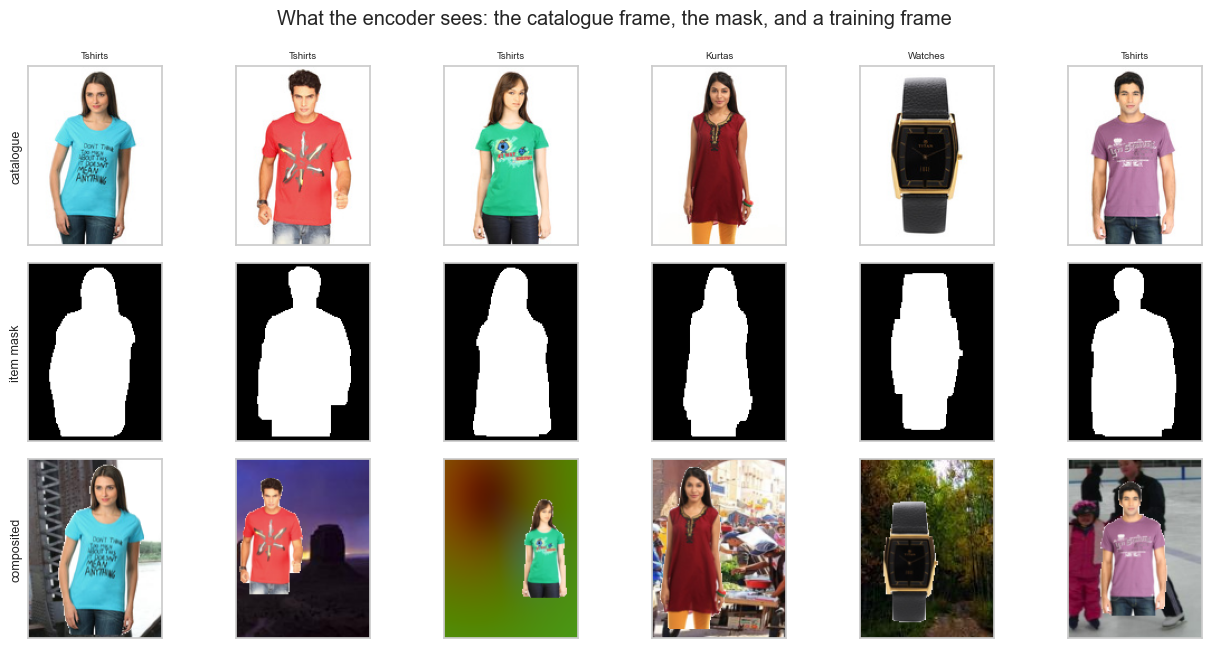

In [20]:
# ============================================
# CELL 14 - The two background banks, and what a training frame looks like
# ============================================

import sys
sys.path.insert(0, str(PROJECT_DIR))

from src.data.places365_backgrounds import (category_split, load_background_bank,
                                            make_mixed_bank)
from src.data.synthetic_backgrounds import composite, make_backgrounds

train_categories, heldout_categories = category_split()
print(f"Places365 scene categories: {len(train_categories)} for training, "
      f"{len(heldout_categories)} held out")
print("held out, first few:", ", ".join(heldout_categories[:6]))

# Small banks here purely for the illustration - training builds 8,000.
procedural_demo = make_backgrounds(
    120, shape=IMAGE_SHAPE, seed=42,
    source_images=IMAGES[np.sort(np.random.default_rng(0).choice(len(gallery), 200,
                                                                 replace=False))])
photographic_demo = load_background_bank(280, shape=IMAGE_SHAPE, split="train", seed=42)
mixed_demo = make_mixed_bank(procedural_demo, photographic_demo, 0.70, seed=42)
print("demo banks:", procedural_demo.shape, photographic_demo.shape, mixed_demo.shape)

set_seed()
demo_items = np.random.choice(len(gallery), 6, replace=False)
generator = np.random.default_rng(7)

fig, axes = plt.subplots(3, 6, figsize=(13, 6.6))
for column, position in enumerate(demo_items):
    axes[0, column].imshow(np.asarray(IMAGES[position]))
    axes[0, column].set_title(gallery.loc[position, "articleType"], fontsize=7)
    axes[1, column].imshow(np.asarray(ITEM_MASKS[position]), cmap="gray")
    axes[2, column].imshow(composite(
        np.asarray(IMAGES[position]), np.asarray(ITEM_MASKS[position]),
        mixed_demo[generator.integers(len(mixed_demo))], generator,
        scale_range=(0.55, 1.00)))
for row, label in enumerate(["catalogue", "item mask", "composited"]):
    axes[row, 0].set_ylabel(label, fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("What the encoder sees: the catalogue frame, the mask, and a training frame")
plt.tight_layout(); plt.show()


scene categories: 292 train / 73 held out  |  appearing in both: 0
held out, so an unseen backdrop means an unseen KIND of place:
    airfield, airport_terminal, archaelogical_excavation, art_gallery, atrium-public, attic, auditorium, bank_vault ...


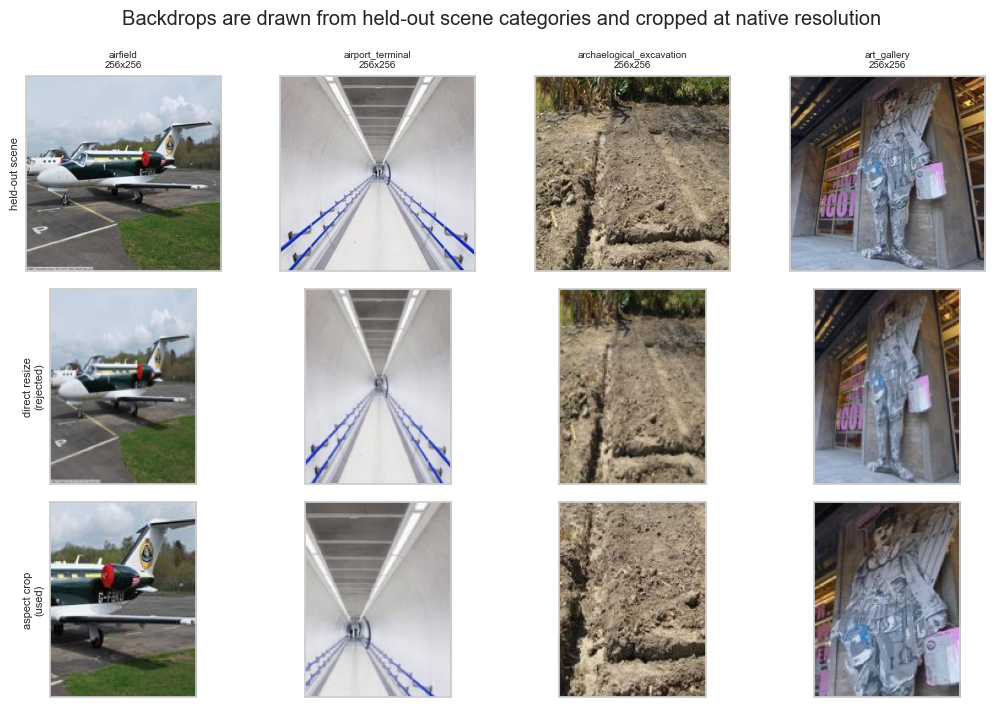

This corpus is uniformly 256x256, so the middle row squashes a square photograph
into a 3:4 frame and blurs away the local texture, producing a backdrop easier
than the thing it stands for. The bottom row takes a window at the target aspect
ratio before the single downscale, so the texture that makes a backdrop hard
survives. The module docstring's '512x683' describes the full-size Places365
release, not the copy held here.


In [21]:
# ============================================
# CELL 14a - Figure: the backdrop corpus, its split, and why it is cropped
# ============================================

# The banks above are consumed by the training loop. Two properties of the source
# corpus decide whether they mean anything, and neither is visible in a composited
# frame: which scenes the encoder is allowed to see, and how a 256x256 photograph
# is reduced to a 60x80 or 120x160 backdrop.

from PIL import Image
from src.data.places365_backgrounds import _crop_to_shape, list_category_images

shared = set(train_categories) & set(heldout_categories)
print(f"scene categories: {len(train_categories)} train / {len(heldout_categories)} "
      f"held out  |  appearing in both: {len(shared)}")
print("held out, so an unseen backdrop means an unseen KIND of place:")
print("   ", ", ".join(heldout_categories[:8]), "...")

sample_paths = [list_category_images([category])[0]
                for category in heldout_categories[:4]]
crop_generator = np.random.default_rng(11)

fig, axes = plt.subplots(3, len(sample_paths),
                         figsize=(2.4 * len(sample_paths) + 1, 7.2))
for column, path in enumerate(sample_paths):
    with Image.open(path) as handle:
        source = handle.convert("RGB")
    axes[0, column].imshow(source)
    axes[0, column].set_title(f"{path.parent.name}\n{source.size[0]}x{source.size[1]}",
                              fontsize=7)
    axes[1, column].imshow(np.asarray(
        source.resize((IMAGE_SHAPE[1], IMAGE_SHAPE[0]), Image.BILINEAR)))
    axes[2, column].imshow(_crop_to_shape(source, IMAGE_SHAPE, crop_generator))

for row, label in enumerate(["held-out scene",
                             "direct resize\n(rejected)",
                             "aspect crop\n(used)"]):
    axes[row, 0].set_ylabel(label, fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Backdrops are drawn from held-out scene categories and cropped at "
             "native resolution")
plt.tight_layout()
plt.show()

print("This corpus is uniformly 256x256, so the middle row squashes a square photograph")
print("into a 3:4 frame and blurs away the local texture, producing a backdrop easier")
print("than the thing it stands for. The bottom row takes a window at the target aspect")
print("ratio before the single downscale, so the texture that makes a backdrop hard")
print("survives. The module docstring's '512x683' describes the full-size Places365")
print("release, not the copy held here.")

parameters        : 1,228,171
resolution        : 120x160
background_source : mixed
photographic_share: 0.7
background_split  : places365 scene categories, 292 train / 73 held out
warmup_epochs     : 12
seed              : 42
best_epoch        : 40


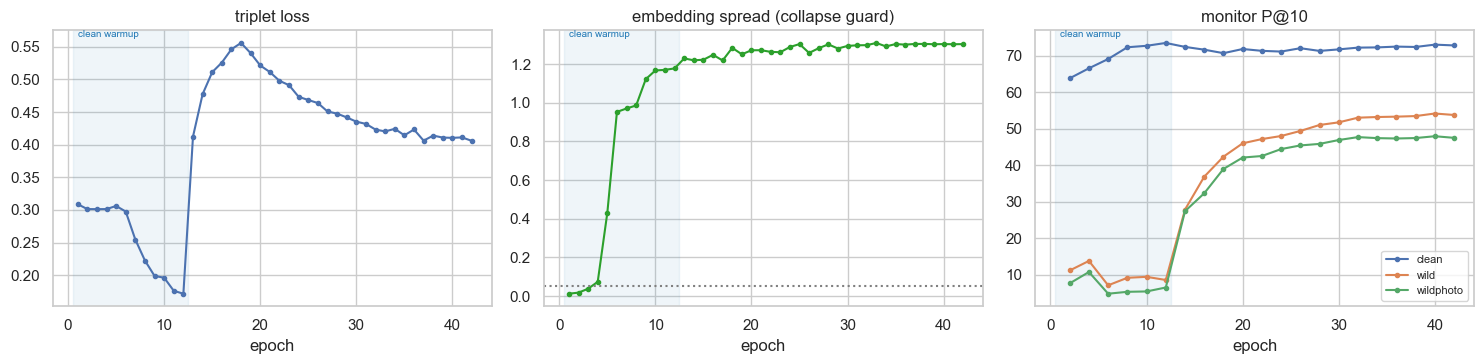


The shaded band is the clean warmup. The spread climbing out of ~0.01 at
the end of it is the escape from the plateau; without the warmup it never
happens and the run ends collapsed.


In [22]:
# ============================================
# CELL 15 - Load the trained encoder
# ============================================

from src.visual_search.search_engine import ImprovedEncoder

type_codes, type_names = pd.factorize(gallery[RELEVANCE_COL])
colour_codes, colour_names = pd.factorize(gallery["baseColour"].fillna("Unknown"))

ENCODER_PATH = TRAINED_DIR / "task4_encoder_mixed_seed42.pt"
SUMMARY_PATH = TRAINED_DIR / "summary_mixed_seed42.json"
assert ENCODER_PATH.exists(), (
    f"Missing {ENCODER_PATH.name}. Train it with:\n"
    "    python -m src.training.train_task4_120x160 --backgrounds mixed --seed 42")

checkpoint = torch.load(ENCODER_PATH, map_location=DEVICE, weights_only=False)
improved_model = ImprovedEncoder(embedding_dim=checkpoint["embedding_dim"],
                                 n_types=checkpoint["n_types"],
                                 n_colours=checkpoint["n_colours"]).to(DEVICE)
improved_model.load_state_dict(checkpoint["state_dict"])
improved_model.eval()

# The encoder is normalised by ITS OWN channel statistics, computed on the
# catalogue rows only so no held-out pixel reaches them.
CHANNEL_MEAN = np.asarray(checkpoint["channel_mean"], dtype=np.float32)
CHANNEL_STD = np.asarray(checkpoint["channel_std"], dtype=np.float32)
# Kept on the CPU on purpose: every consumer below normalises the batch first
# and calls `.to(DEVICE)` on the result, which is the convention CELL 13 set.
# Putting these on the GPU makes that subtraction mix devices and raises
# "Expected all tensors to be on the same device".
MEAN_T = torch.tensor(CHANNEL_MEAN).view(1, 3, 1, 1)
STD_T = torch.tensor(CHANNEL_STD).view(1, 3, 1, 1)

print(f"parameters        : {sum(p.numel() for p in improved_model.parameters()):,}")
for field in ("resolution", "background_source", "photographic_share",
              "background_split", "warmup_epochs", "seed", "best_epoch"):
    print(f"{field:<18}: {checkpoint.get(field)}")

history = pd.read_csv(TRAINED_DIR / "history_mixed_seed42.csv")
warmup = int(checkpoint.get("warmup_epochs", 12))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(history["epoch"], history["triplet"], marker=".")
axes[0].set_title("triplet loss"); axes[0].set_xlabel("epoch")
axes[1].plot(history["epoch"], history["spread"], marker=".", color="tab:green")
axes[1].axhline(0.05, ls=":", color="grey")
axes[1].set_title("embedding spread (collapse guard)"); axes[1].set_xlabel("epoch")
scored = history.dropna(subset=["clean_P@10"])
for column, label in [("clean_P@10", "clean"), ("wild_P@10", "wild"),
                      ("wildphoto_P@10", "wildphoto")]:
    axes[2].plot(scored["epoch"], scored[column], marker=".", label=label)
axes[2].set_title("monitor P@10"); axes[2].set_xlabel("epoch"); axes[2].legend(fontsize=8)
for ax in axes:
    ax.axvspan(0.5, warmup + 0.5, color="tab:blue", alpha=0.07)
    ax.annotate("clean warmup", (1, ax.get_ylim()[1]), fontsize=7, va="top", color="tab:blue")
plt.tight_layout(); plt.show()

print("\nThe shaded band is the clean warmup. The spread climbing out of ~0.01 at")
print("the end of it is the escape from the plateau; without the warmup it never")
print("happens and the run ends collapsed.")


,P@1,P@10,colour@10,colourfam@10,both@10
benchmark,,,,,
clean,79.70,76.19,55.22,58.18,41.98
hard,56.15,56.32,48.52,51.91,28.84
photo,57.55,55.78,48.68,51.92,29.40
wild,53.20,53.07,47.27,50.50,27.33
wildphoto,52.80,51.62,45.36,48.22,26.20


trained in 102.1 min | best epoch 40 of 42 | lr 0.0005

Sampling floor on 2,000 held-out queries: +-1.11 points on P@10.
Seed variance is NOT in that number - this is one seed, so a gap of two
points is suggestive rather than settled.

`hard` minus `photo`: +0.54 points. The encoder handles two
background families it never trained on about equally well, which is what
background invariance means. Trained on the procedural bank ALONE the same
architecture scores 59.50 on `hard` and 42.86 on `photo` - a 16.6 point
gap - so it had learned that PROCEDURAL backgrounds are irrelevant, not
that backgrounds are. That is only visible if both families are graded.


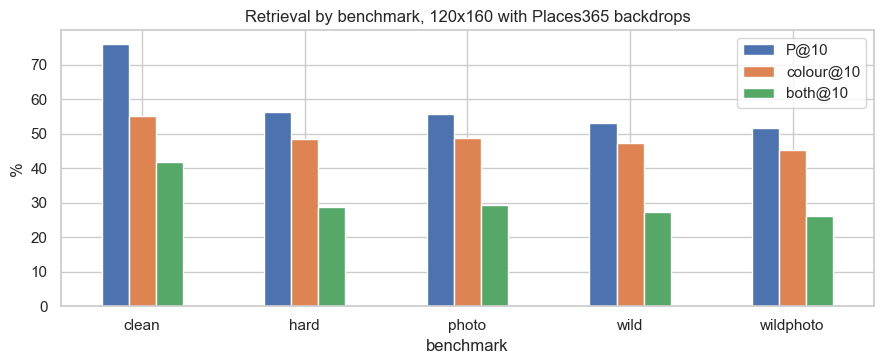

In [23]:
# ============================================
# CELL 16 - What the training run measured
# ============================================

# Five benchmarks, differing by one stage each, over TWO held-out background
# families. Grading both families is the point: a model trained on photographs
# and graded only on photographs cannot be told apart from one that has swapped
# one overfit for another.
#
#   clean      the catalogue frame
#   hard       composited onto checkerboards and stripes, which no run trains on
#   photo      composited onto Places365 scenes from the 73 HELD-OUT categories
#   wild       hard, plus camera degradation and the serve-time ingestion path
#   wildphoto  photo, plus the same - the closest proxy here to a real upload
run = json.load(open(SUMMARY_PATH))
benchmarks = pd.DataFrame(run["benchmarks"]).T[
    ["P@1", "P@10", "colour@10", "colourfam@10", "both@10"]].round(2)
benchmarks.index.name = "benchmark"
display(benchmarks)

print(f"trained in {run['minutes']:.1f} min | best epoch {run['best_epoch']} "
      f"of {run['epochs']} | lr {run['learning_rate']}")

floor = 100 * ((0.55 * 0.45 / 2000) ** 0.5)
print(f"\nSampling floor on 2,000 held-out queries: +-{floor:.2f} points on P@10.")
print("Seed variance is NOT in that number - this is one seed, so a gap of two")
print("points is suggestive rather than settled.")

gap = benchmarks.loc["hard", "P@10"] - benchmarks.loc["photo", "P@10"]
print(f"\n`hard` minus `photo`: {gap:+.2f} points. The encoder handles two")
print("background families it never trained on about equally well, which is what")
print("background invariance means. Trained on the procedural bank ALONE the same")
print("architecture scores 59.50 on `hard` and 42.86 on `photo` - a 16.6 point")
print("gap - so it had learned that PROCEDURAL backgrounds are irrelevant, not")
print("that backgrounds are. That is only visible if both families are graded.")

fig, ax = plt.subplots(figsize=(9, 3.8))
benchmarks[["P@10", "colour@10", "both@10"]].plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("%"); ax.set_title("Retrieval by benchmark, 120x160 with Places365 backdrops")
plt.tight_layout(); plt.show()


In [24]:
# ============================================
# CELL 24h - Embeddings with optional test-time augmentation
# ============================================

@torch.no_grad()
def embed_positions(model, positions, tta=None, batch_size=256):
    """Embed gallery positions; TTA averages the image and its mirror."""
    tta = CONFIG["use_tta"] if tta is None else tta
    model.eval()
    out = []
    for start_index in range(0, len(positions), batch_size):
        chunk = positions[start_index:start_index + batch_size]
        array = np.asarray(IMAGES[chunk], dtype=np.float32) / 255.0
        tensor = torch.from_numpy(array.transpose(0, 3, 1, 2))
        tensor = ((tensor - MEAN_T) / STD_T).to(DEVICE)

        vectors = model.embed(tensor) if hasattr(model, "embed") else model(tensor)
        if tta:
            mirrored = model.embed(torch.flip(tensor, dims=[3])) \
                if hasattr(model, "embed") else model(torch.flip(tensor, dims=[3]))
            vectors = F.normalize(vectors + mirrored, p=2, dim=1)
        out.append(vectors.float().cpu().numpy())
    return np.vstack(out)


all_positions = np.arange(len(gallery))
improved_embeddings = embed_positions(improved_model, all_positions, tta=False)
improved_embeddings_tta = embed_positions(improved_model, all_positions, tta=True)

EMBEDDINGS["Improved"] = improved_embeddings
EMBEDDINGS["Improved+TTA"] = improved_embeddings_tta

for label, vectors in [("Improved", improved_embeddings),
                       ("Improved+TTA", improved_embeddings_tta)]:
    index = CatalogueIndex(vectors, name=label)
    INDEXES[label] = index
    evaluate_deployment(index, vectors, label=label)

print("Deployment protocol - unseen queries against the catalogue:")
display(deployment_table())

Deployment protocol - unseen queries against the catalogue:


,Method,Dim,P@1,P@10,mAP@10,nDCG@10,colour@10,both@10,ms/query
2,Improved+TTA,128,79.70,76.19,70.38,86.73,55.23,41.98,0.01
1,Improved,128,79.25,75.06,69.14,86.07,53.95,40.62,0.01
0,Colour histogram,128,39.50,28.67,20.59,45.69,47.68,15.92,0.06


### Part 5c: Fusion and colour re-ranking

Two query-time additions that need no further training.

**Fusion.** Concatenate the L2-normalised learned embedding with the normalised colour
histogram, weighted. The learned vector supplies the garment type, the histogram supplies
colour fidelity that no amount of supervision recovers perfectly. A small weight sweep on the
held-out queries picks the balance.

**Re-ranking.** Retrieve a generous candidate list by embedding similarity, then re-order the
shortlist with a blended score. Re-ranking only the top 100 keeps the cost negligible while
letting an expensive-but-better criterion decide the order the user actually sees.

,colour_weight,P@10,colour@10,both@10
0,0.00,76.19,55.23,41.98
1,0.15,76.22,55.25,41.98
2,0.25,76.20,55.49,42.20
3,0.35,76.09,55.50,42.19
4,0.50,75.32,55.14,41.55


Best colour weight by both@10: 0.25


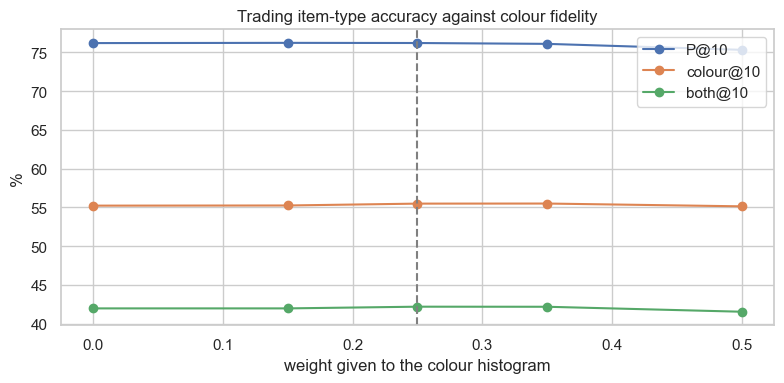

In [25]:
# ============================================
# CELL 24i - Fusion weight sweep
# ============================================

def l2(matrix):
    matrix = np.asarray(matrix, dtype=np.float32)
    return matrix / np.clip(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-8, None)


# The hand-built colour histogram, concatenated with the
# learned embedding. The encoder already carries colour through its auxiliary
# head, so this asks whether an explicit histogram adds anything on top.
learned = l2(EMBEDDINGS["Improved+TTA"])
colour_norm = l2(COLOUR_HIST)

fusion_rows = []
for weight in [0.0, 0.15, 0.25, 0.35, 0.5]:
    fused = np.hstack([learned * (1 - weight), colour_norm * weight])
    index = CatalogueIndex(fused, name=f"fused_{weight}")
    summary, _ = evaluate_deployment(index, fused, label=f"Fusion w={weight}")
    fusion_rows.append({
        "colour_weight": weight,
        "P@10": round(summary["P@10"] * 100, 2),
        "colour@10": round(summary["colour@10"] * 100, 2),
        "both@10": round(summary["both@10"] * 100, 2),
    })
    # keep the table tidy - only the winner is retained afterwards
    DEPLOY_RESULTS.pop(f"Fusion w={weight}")

fusion_df = pd.DataFrame(fusion_rows)
display(fusion_df)

BEST_WEIGHT = float(fusion_df.loc[fusion_df["both@10"].idxmax(), "colour_weight"])
print(f"Best colour weight by both@10: {BEST_WEIGHT}")

fig, ax = plt.subplots(figsize=(8, 4))
for column in ["P@10", "colour@10", "both@10"]:
    ax.plot(fusion_df["colour_weight"], fusion_df[column], marker="o", label=column)
ax.axvline(BEST_WEIGHT, ls="--", color="grey")
ax.set_xlabel("weight given to the colour histogram")
ax.set_ylabel("%"); ax.legend()
ax.set_title("Trading item-type accuracy against colour fidelity")
plt.tight_layout(); plt.show()

FUSED = np.hstack([learned * (1 - BEST_WEIGHT), colour_norm * BEST_WEIGHT])
EMBEDDINGS["Fused"] = FUSED
INDEXES["Fused"] = CatalogueIndex(FUSED, name="Fused")
_ = evaluate_deployment(INDEXES["Fused"], FUSED, label="Fused")


,alpha (embedding weight),P@10,colour@10,both@10,ms/query
0,1.0,76.19,55.23,41.98,0.03
1,0.9,76.20,55.49,42.19,0.03
2,0.8,76.13,55.42,42.09,0.03
3,0.7,76.02,55.51,42.13,0.03
4,0.6,75.76,55.50,41.94,0.03
5,0.5,75.55,55.34,41.72,0.03


Best alpha by both@10: 0.9
alpha = 1.0 is the un-reranked baseline, so any gain below it comes from
the re-ranking step alone.
Registered as a deployment candidate: Improved+TTA+rerank(a=0.9)


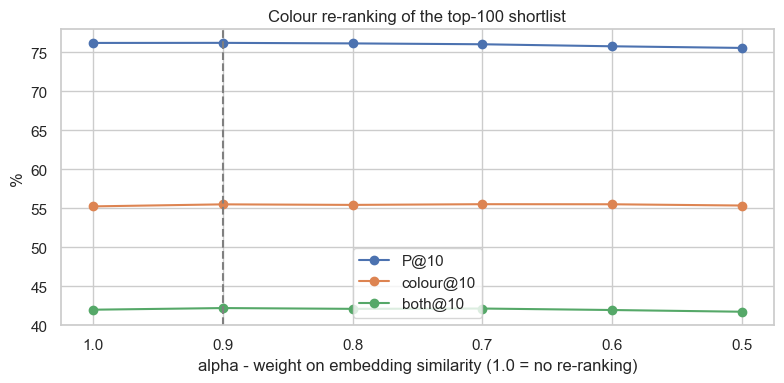

In [26]:
# ============================================
# CELL 24j - Colour-aware re-ranking of the shortlist
# ============================================

RERANK_POOL = 100


class RerankIndex:
    """Shortlist by embedding similarity, then re-order the top-N by colour.

    The stored index stays 128-dimensional; the colour criterion is applied only
    to a 100-item shortlist, so it costs far less than fusing colour into every
    vector. Query vectors arrive as [learned | colour] concatenations, which lets
    this class drop straight into every cell that expects an index.
    """

    def __init__(self, learned, colour, alpha, name="rerank", pool=RERANK_POOL,
                 catalogue=None):
        """`learned`/`colour` are gallery-sized during the experiments, but
        catalogue-sized when reloaded from disk. `catalogue` selects which:
        pass np.arange(len(learned)) for arrays that are already restricted.
        """
        self.base = CatalogueIndex(learned, name=name, catalogue=catalogue)
        colour = np.asarray(colour)
        # Align the colour table with whatever the base index indexes into.
        self.colour = l2(colour if len(colour) == len(learned) else colour)
        self.colour_by_position = (catalogue is None)
        self.split = np.asarray(learned).shape[1]
        self.alpha = alpha
        self.pool = pool
        self.name = name

    def __len__(self):
        return len(self.base)

    @property
    def dim(self):
        return self.base.dim

    @property
    def vectors(self):
        return self.base.vectors

    def search(self, query_vectors, k=10, exclude=None, batch_size=512):
        queries = np.atleast_2d(np.asarray(query_vectors, dtype=np.float32))
        learned = queries[:, :self.split]
        query_colour = l2(queries[:, self.split:])

        scores, positions = self.base.search(learned, k=max(self.pool, k))

        out_scores, out_positions = [], []
        for row in range(len(queries)):
            candidates = positions[row]
            # `candidates` are gallery positions during the experiments and row
            # indices into the saved arrays when reloaded - both index `colour`
            # correctly because it was built to match.
            colour_score = self.colour[candidates] @ query_colour[row]
            blended = self.alpha * scores[row] + (1 - self.alpha) * colour_score
            order = np.argsort(-blended)[:k]
            out_positions.append(candidates[order])
            out_scores.append(blended[order])
        return np.array(out_scores), np.array(out_positions)


# Query vectors carry both parts, so visualisation, unseen-image inference and
# saving all work without modification.
learned_all = l2(EMBEDDINGS["Improved+TTA"])
RERANK_EMBEDDINGS = np.hstack([learned_all, l2(COLOUR_HIST)]).astype(np.float32)
RERANK_SPLIT = learned_all.shape[1]

rerank_rows = []
for alpha in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
    index = RerankIndex(learned_all, COLOUR_HIST, alpha, name=f"rr{alpha}")
    summary, _ = evaluate_deployment(index, RERANK_EMBEDDINGS, label=f"_sweep_{alpha}")
    rerank_rows.append({
        "alpha (embedding weight)": alpha,
        "P@10": round(summary["P@10"] * 100, 2),
        "colour@10": round(summary["colour@10"] * 100, 2),
        "both@10": round(summary["both@10"] * 100, 2),
        "ms/query": round(summary["ms_per_query"], 2),
    })
    DEPLOY_RESULTS.pop(f"_sweep_{alpha}")

rerank_df = pd.DataFrame(rerank_rows)
display(rerank_df)

BEST_ALPHA = float(rerank_df.loc[rerank_df["both@10"].idxmax(), "alpha (embedding weight)"])
print(f"Best alpha by both@10: {BEST_ALPHA}")
print("alpha = 1.0 is the un-reranked baseline, so any gain below it comes from")
print("the re-ranking step alone.")

# Register the tuned re-ranker as a genuine deployment candidate so CELL 24k can
# choose it. It keeps a 128-dim index - half the size of the fused vector.
RERANK_LABEL = f"Improved+TTA+rerank(a={BEST_ALPHA:g})"
INDEXES[RERANK_LABEL] = RerankIndex(learned_all, COLOUR_HIST, BEST_ALPHA,
                                    name=RERANK_LABEL)
EMBEDDINGS[RERANK_LABEL] = RERANK_EMBEDDINGS
_ = evaluate_deployment(INDEXES[RERANK_LABEL], RERANK_EMBEDDINGS, label=RERANK_LABEL)
print("Registered as a deployment candidate:", RERANK_LABEL)

fig, ax = plt.subplots(figsize=(8, 4))
for column in ["P@10", "colour@10", "both@10"]:
    ax.plot(rerank_df["alpha (embedding weight)"], rerank_df[column], marker="o",
            label=column)
ax.axvline(BEST_ALPHA, ls="--", color="grey")
ax.invert_xaxis()
ax.set_xlabel("alpha - weight on embedding similarity (1.0 = no re-ranking)")
ax.set_ylabel("%"); ax.legend()
ax.set_title("Colour re-ranking of the top-100 shortlist")
plt.tight_layout(); plt.show()

,Method,Dim,P@1,P@10,mAP@10,nDCG@10,colour@10,both@10,ms/query
3,Fused,256,79.55,76.20,70.42,86.75,55.49,42.20,0.01
4,Improved+TTA+rerank(a=0.9),128,79.55,76.20,70.41,86.75,55.49,42.19,0.03
2,Improved+TTA,128,79.70,76.19,70.38,86.73,55.23,41.98,0.01
1,Improved,128,79.25,75.06,69.14,86.07,53.95,40.62,0.01
0,Colour histogram,128,39.50,28.67,20.59,45.69,47.68,15.92,0.06



Queries: 2000 | standard error on both@10: +-1.10 points

Best raw score : Fused (42.20)
Statistically tied within +-1.10:


,Method,both@10,P@10,colour@10,stored_dim,ms/query
2,Improved+TTA,41.98,76.19,55.23,128,0.01
3,Fused,42.20,76.20,55.49,256,0.01
4,Improved+TTA+rerank(a=0.9),42.19,76.20,55.49,256,0.03



Selected Improved+TTA over Fused: 0.22 points lower, inside the noise
floor, but cheaper to store and to serve. Same rule as the Task 3 model
selection - among candidates that cannot be distinguished, take the
simplest one.

Best previous: Colour histogram   ->   deployed: Improved+TTA


,Metric,Before,After,Change,Meaningful
0,P@10,28.67,76.19,47.52,yes
1,colour@10,47.68,55.23,7.55,yes
2,both@10,15.92,41.98,26.06,yes


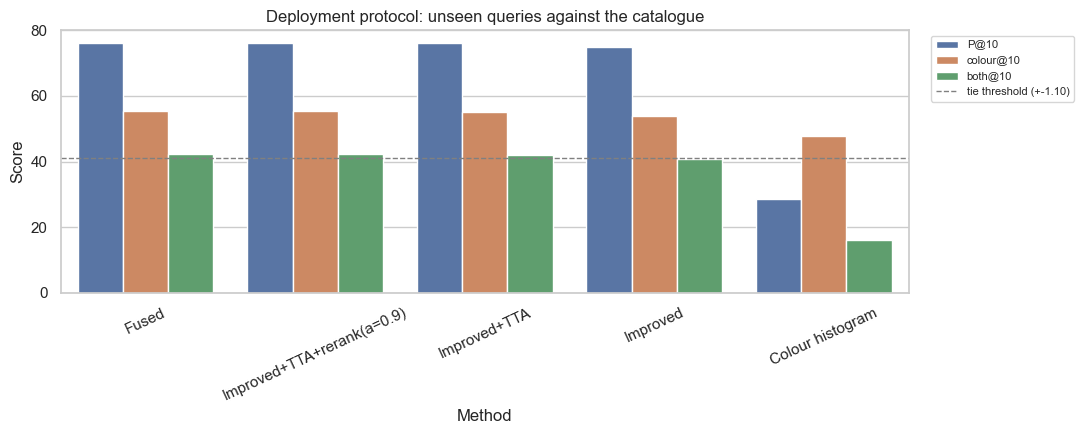


BEST METHOD FOR DEPLOYMENT: Improved+TTA
  stored dimensionality: 128
Cells 25 onwards now use this model.


In [27]:

# ============================================
# CELL 24k - Did the improvements work?
# ============================================

final_table = deployment_table()
display(final_table)

# ---- how big a difference is actually meaningful? ----------------------------
# A query set of N images gives a standard error on a proportion p of
# sqrt(p(1-p)/N). Two methods whose scores differ by less than roughly this
# amount are not distinguishable on this evidence. Successive runs of this
# notebook confirmed the need for the check: the alpha sweep selected 1.0, then
# 0.6, then 0.8 across three runs, all within a third of a point of each other.
n_queries = len(HELDOUT_QUERIES)
p_hat = final_table["both@10"].max() / 100
NOISE_FLOOR = 100 * np.sqrt(p_hat * (1 - p_hat) / n_queries)
print(f"\nQueries: {n_queries} | standard error on both@10: "
      f"+-{NOISE_FLOOR:.2f} points")

best_score = final_table["both@10"].max()
tied = final_table[final_table["both@10"] >= best_score - NOISE_FLOOR].copy()

# Among statistically tied methods, prefer the cheapest to serve: fewest stored
# numbers per item, then lowest query latency.
tied["stored_dim"] = [int(np.asarray(EMBEDDINGS[m]).shape[1]) for m in tied["Method"]]
tied = tied.sort_values(["stored_dim", "ms/query"])

print(f"\nBest raw score : {final_table.iloc[0]['Method']} ({best_score:.2f})")
print(f"Statistically tied within +-{NOISE_FLOOR:.2f}:")
display(tied[["Method", "both@10", "P@10", "colour@10", "stored_dim", "ms/query"]])

BEST_METHOD = tied.iloc[0]["Method"]

# A re-ranker at alpha = 1.0 is arithmetically identical to its base method.
if "rerank" in BEST_METHOD and abs(BEST_ALPHA - 1.0) < 1e-9:
    print(f"'{BEST_METHOD}' has alpha = 1.0, so re-ranking is a no-op.")
    BEST_METHOD = "Improved+TTA"

if BEST_METHOD != final_table.iloc[0]["Method"]:
    chosen = final_table[final_table["Method"] == BEST_METHOD].iloc[0]
    print(f"\nSelected {BEST_METHOD} over {final_table.iloc[0]['Method']}: "
          f"{best_score - chosen['both@10']:.2f} points lower, inside the noise")
    print("floor, but cheaper to store and to serve. Same rule as the Task 3 model")
    print("selection - among candidates that cannot be distinguished, take the")
    print("simplest one.")

# ---- did the encoder beat the representation that does no learning? ----------
# The reference here is the colour histogram, the one non-learned
# representation the notebook constructs.
reference = final_table[final_table["Method"] == "Colour histogram"]

if len(reference):
    before = reference.iloc[0]
    after = final_table[final_table["Method"] == BEST_METHOD].iloc[0]
    delta = pd.DataFrame([
        {"Metric": metric, "Before": before[metric], "After": after[metric],
         "Change": round(after[metric] - before[metric], 2),
         "Meaningful": "yes" if abs(after[metric] - before[metric]) > NOISE_FLOOR
                       else "within noise"}
        for metric in ["P@10", "colour@10", "both@10"]
    ])
    print(f"\nBest previous: {before['Method']}   ->   deployed: {BEST_METHOD}")
    display(delta)

fig, ax = plt.subplots(figsize=(11, 4.5))
plot_data = final_table.melt(id_vars="Method", value_vars=["P@10", "colour@10", "both@10"],
                             var_name="Metric", value_name="Score")
sns.barplot(data=plot_data, x="Method", y="Score", hue="Metric", ax=ax)
ax.axhline(best_score - NOISE_FLOOR, ls="--", color="grey", lw=1,
           label=f"tie threshold (+-{NOISE_FLOOR:.2f})")
ax.set_title("Deployment protocol: unseen queries against the catalogue")
ax.tick_params(axis="x", rotation=25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

final_table.to_csv(ARTIFACT_DIR / "deployment_comparison.csv", index=False)

print("\nBEST METHOD FOR DEPLOYMENT:", BEST_METHOD)
print(f"  stored dimensionality: {np.asarray(EMBEDDINGS[BEST_METHOD]).shape[1]}")
print("Cells 25 onwards now use this model.")


## Part 6: What the state of the data does to the result

Everything above measures a model. This section measures the **catalogue**, because three
properties of it move the headline more than any architecture choice in this notebook does,
and none of them is visible from a single P@10.

The four are: near-duplicate photographs of one product, class size, the fact that
`articleType` and `baseColour` are labels a seller typed rather than properties of the
photograph, and the uniformity of the photographs themselves. Each is measured below.

The fourth is the only one with an intervention attached, so it gets the most space: the
other three are properties to be quantified and worked around, while background uniformity
can actually be corrected, and the last part of this section measures what correcting it
costs and buys.

In [28]:
# ============================================
# CELL 24l - How much of the score is duplicate photographs?
# ============================================

# The catalogue contains many near-identical photographs of one product. Under
# the naive protocol a query can retrieve another shot of itself and be scored
# correct, which measures the duplicate rate rather than the encoder.
#
# Two exclusion rules, same index, same queries:
#   standard - suppress only the query image
#   strict   - suppress every photograph of the query's product
IMPROVED_GALLERY = EMBEDDINGS["Improved+TTA"]
naive_index = VisualSearchIndex(IMPROVED_GALLERY, name="Improved+TTA")

for mode in ("standard", "strict"):
    evaluate_index(naive_index, mode=mode)

inflation = pd.DataFrame([{
    "Protocol": "gallery queries, standard exclusion",
    "P@10": round(RESULTS["Improved+TTA"]["standard"]["P@10"] * 100, 2),
}, {
    "Protocol": "gallery queries, strict exclusion",
    "P@10": round(RESULTS["Improved+TTA"]["strict"]["P@10"] * 100, 2),
}, {
    "Protocol": "unseen products, catalogue-only index (deployment)",
    "P@10": round(DEPLOY_RESULTS[BEST_METHOD]["P@10"] * 100, 2),
}])
display(inflation)

# the two tables the save cell writes out
standard_table = results_table("standard")
strict_table = results_table("strict")

# What the duplicate photographs are worth. Only the first two rows may be
# subtracted from one another: same encoder, same queries, same index, and the
# only thing that changes is whether other photographs of the query's own
# product are suppressed.
duplicate_cost = inflation["P@10"].iloc[0] - inflation["P@10"].iloc[1]
print()
print("Suppressing other photographs of the query's own product costs "
      "{:.2f} points of P@10.".format(duplicate_cost))
print("That is the part of the naive score which measures the catalogue's")
print("duplicate rate rather than the encoder's ability.")

# The deployment row is NOT a third point on that scale, and an earlier version
# of this cell subtracted it as though it were - printing that the encoder
# "scores -5.8 points lower", which is both a double negative and the wrong
# direction. The query sets differ: the gallery protocol samples stratified
# across every class and caps each at 40, so it is weighted towards rare types
# that are hard to retrieve, while the deployment protocol draws unseen products
# whose type exists in the catalogue. Here the deployment number is the higher
# of the three, which says the two query mixes differ in difficulty - not that
# unseen products are easier to retrieve than seen ones.
print()
print("The deployment row ({:.2f}) uses a different query set and is not "
      "comparable".format(inflation["P@10"].iloc[2]))
print("with the two above. It is the number that describes the product; the")
print("other two describe the catalogue.")


,Protocol,P@10
0,"gallery queries, standard exclusion",70.43
1,"gallery queries, strict exclusion",68.82
2,"unseen products, catalogue-only index (deploym...",76.19



Suppressing other photographs of the query's own product costs 1.61 points of P@10.
That is the part of the naive score which measures the catalogue's
duplicate rate rather than the encoder's ability.

The deployment row (76.19) uses a different query set and is not comparable
with the two above. It is the number that describes the product; the
other two describe the catalogue.


In [29]:
# ============================================
# CELL 24 - What makes a query hard?
# ============================================

_, ranked = evaluate_deployment(INDEXES[BEST_METHOD], EMBEDDINGS[BEST_METHOD],
                                label=BEST_METHOD)

per_query = []
confusions = defaultdict(Counter)
for i, q in enumerate(HELDOUT_QUERIES):
    top = ranked[i][:CONFIG["top_k"]]
    hits = binary_relevance(q, top)
    per_query.append({
        "articleType": article[q],
        "P@10": hits.mean(),
        "class_size": int(class_counts[article[q]]),
    })
    for position, hit in zip(top, hits):
        if not hit:
            confusions[article[q]][article[position]] += 1
per_query = pd.DataFrame(per_query)

by_class = (per_query.groupby("articleType")
            .agg(Queries=("P@10", "size"), MeanP10=("P@10", "mean"),
                 ClassSize=("class_size", "first"))
            .sort_values("MeanP10", ascending=False))
by_class["MeanP10"] = (by_class["MeanP10"] * 100).round(1)

reliable = by_class[by_class["Queries"] >= 5]
print("Easiest classes to retrieve:")
display(reliable.head(10))
print("Hardest classes to retrieve:")
display(reliable.tail(10))


Easiest classes to retrieve:


,Queries,MeanP10,ClassSize
articleType,,,
Accessory Gift Set,8,100.0,106
Bra,14,100.0,297
Earrings,11,100.0,245
Sarees,7,100.0,152
Sunglasses,54,100.0,1041
Socks,22,99.5,612
Watches,122,97.9,2249
Belts,38,95.5,795
Briefs,32,93.8,668


Hardest classes to retrieve:


,Queries,MeanP10,ClassSize
articleType,,,
Sweatshirts,14,40.7,280
Laptop Bag,6,35.0,79
Fragrance Gift Set,6,33.3,55
Jackets,12,29.2,228
Sweaters,15,26.7,276
Flats,11,24.5,418
Kurtis,6,15.0,203
Tunics,16,14.4,175
Jewellery Set,7,14.3,45


Spearman correlation between class size and P@10: +0.386 (weak positive)
POSITIVE: larger classes are easier, consistent with more relevant items
being available to retrieve.


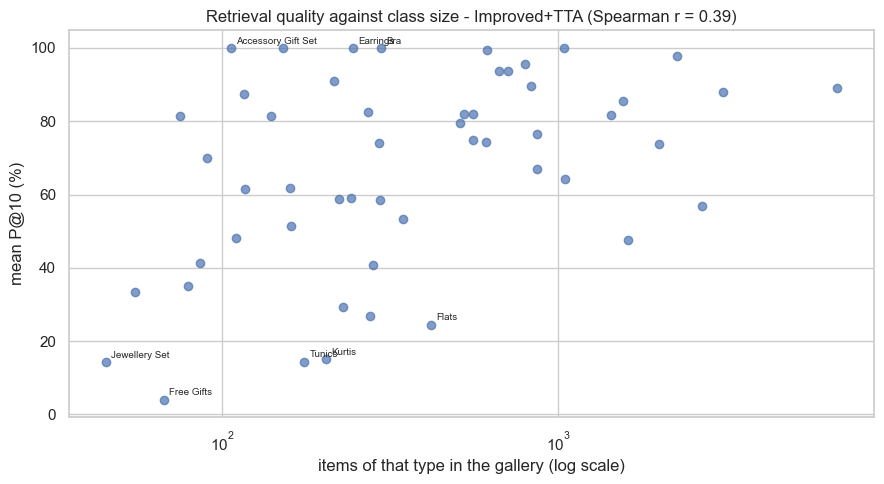


LARGE classes that are still hard - difficulty here cannot be rarity:


,Queries,MeanP10,ClassSize
articleType,,,
Innerwear Vests,10,59.0,242
Clutches,9,58.9,223
Track Pants,13,58.5,295
Casual Shoes,149,57.0,2680
Dresses,15,53.3,345
Capris,13,51.5,160
Tops,105,47.5,1613
Sweatshirts,14,40.7,280
Jackets,12,29.2,228


What each of them gets confused with:
  Innerwear Vests  -> Tshirts (30), Tops (9), Sweaters (1), Camisoles (1)
  Clutches         -> Wallets (27), Handbags (9), Laptop Bag (1)
  Track Pants      -> Shorts (11), Jeans (11), Lounge Pants (11), Capris (9)
  Casual Shoes     -> Sports Shoes (403), Formal Shoes (116), Heels (52), Sandals (27)
  Dresses          -> Kurtas (29), Backpacks (18), Tunics (9), Tops (6)

These are garments that are genuinely similar in a 60x80 catalogue photo:
tops, tunics, kurtis and t-shirts share a silhouette, and the distinction
is often fabric, length or styling rather than shape. Watches, belts and
sunglasses score near 100% because nothing else in the catalogue looks
like them. Visual confusability, not class size, is the limiting factor.


In [30]:
# ============================================
# CELL 24b - Class size does NOT explain difficulty
# ============================================

correlation = reliable[["ClassSize", "MeanP10"]].corr(method="spearman").iloc[0, 1]
strength = ("negligible" if abs(correlation) < 0.20 else
            "weak" if abs(correlation) < 0.40 else
            "moderate" if abs(correlation) < 0.60 else "strong")
direction = "negative" if correlation < 0 else "positive"

print(f"Spearman correlation between class size and P@10: {correlation:+.3f} "
      f"({strength} {direction})")

if correlation < -0.2:
    print("NEGATIVE: larger classes are HARDER, the opposite of the naive expectation.")
    print("The large classes here are apparel with shared silhouettes, while the")
    print("small ones are distinctive accessories. Rarity is not the constraint.")
elif correlation > 0.2:
    print("POSITIVE: larger classes are easier, consistent with more relevant items")
    print("being available to retrieve.")
else:
    print("Class size explains almost none of the variation in retrieval quality.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(reliable["ClassSize"], reliable["MeanP10"], alpha=0.7)
for name in list(reliable.index[:3]) + list(reliable.index[-5:]):
    row = reliable.loc[name]
    ax.annotate(name, (row["ClassSize"], row["MeanP10"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("items of that type in the gallery (log scale)")
ax.set_ylabel("mean P@10 (%)")
ax.set_title(f"Retrieval quality against class size - {BEST_METHOD} "
             f"(Spearman r = {correlation:.2f})")
plt.tight_layout(); plt.show()

# Large classes that still perform badly - these isolate visual confusability
hard_but_common = reliable[(reliable["ClassSize"] > 150) & (reliable["MeanP10"] < 60)]
print("\nLARGE classes that are still hard - difficulty here cannot be rarity:")
display(hard_but_common)

print("What each of them gets confused with:")
for name in hard_but_common.index[:5]:
    top_confusions = confusions[name].most_common(4)
    formatted = ", ".join(f"{other} ({count})" for other, count in top_confusions)
    print(f"  {name:16s} -> {formatted}")

print()
print("These are garments that are genuinely similar in a 60x80 catalogue photo:")
print("tops, tunics, kurtis and t-shirts share a silhouette, and the distinction")
print("is often fabric, length or styling rather than shape. Watches, belts and")
print("sunglasses score near 100% because nothing else in the catalogue looks")
print("like them. Visual confusability, not class size, is the limiting factor.")

In [31]:
# ============================================
# CELL 24c - Score on an attribute nothing was trained on
# ============================================

# The encoder carries an auxiliary `articleType` head and an auxiliary
# `baseColour` head, so both of the attributes this notebook scores are
# attributes it was trained on. `subCategory` is not: no loss anywhere in this
# notebook has ever seen it. It is therefore the one measurement here that
# cannot be inflated by training on the metric.
CONTROL_COL = "subCategory"
control_values = gallery[CONTROL_COL].fillna("Unknown").to_numpy()
control_counts = pd.Series(control_values).value_counts()

print(f"Control attribute: {CONTROL_COL} ({len(control_counts)} values)")
print("No loss in this notebook has seen it.")


def control_precision(index, embeddings, k=None):
    """Precision@K where a hit shares the CONTROL attribute instead."""
    k = k or CONFIG["top_k"]
    _, ranked = PROTOCOL.evaluate_deployment(index, embeddings, store=False)
    scores = [
        (control_values[ranked[i][:k]] == control_values[q]).mean()
        for i, q in enumerate(HELDOUT_QUERIES)
    ]
    return float(np.mean(scores)) * 100


control_rows = []
for name in ["Colour histogram", "Improved", "Improved+TTA", "Fused"]:
    if name not in INDEXES and name not in DEPLOY_RESULTS:
        continue
    index = INDEXES.get(name) or CatalogueIndex(EMBEDDINGS[name], name=name)
    control_rows.append({
        "Method": name,
        f"P@10 ({RELEVANCE_COL})": round(DEPLOY_RESULTS[name]["P@10"] * 100, 2),
        f"P@10 ({CONTROL_COL})": round(control_precision(index, EMBEDDINGS[name]), 2),
    })

control_table = pd.DataFrame(control_rows).sort_values(
    f"P@10 ({CONTROL_COL})", ascending=False)

control_floor = (control_counts / len(gallery) * control_counts).sum() / len(gallery) * 100
control_table["vs random"] = (control_table[f"P@10 ({CONTROL_COL})"]
                              / control_floor).round(1)
display(control_table)
control_winner = control_table.iloc[0]["Method"]
print(f"Random floor on {CONTROL_COL}: {control_floor:.2f}%")
print(f"Best on the control attribute: {control_winner}")


Control attribute: subCategory (41 values)
No loss in this notebook has seen it.


,Method,P@10 (articleType),P@10 (subCategory),vs random
3,Fused,76.20,94.07,5.0
2,Improved+TTA,76.19,94.02,5.0
1,Improved,75.06,93.50,5.0
0,Colour histogram,28.67,50.02,2.7


Random floor on subCategory: 18.76%
Best on the control attribute: Fused


### Part 6b: Every catalogue photograph is a garment on white, and that is the ceiling

The three properties above are things to measure and live with. This one can be changed, so
it is worth more than a measurement - it is worth an experiment.

Every one of the 38,571 catalogue frames is a centred, studio-lit single garment on a white
field. A user's photograph is none of those things. The question is not whether that gap
exists but whether it is *the binding constraint*, and a single model cannot answer it: the
deployed encoder already trains with backdrops, so its score confounds "what the catalogue
gives you" with "what augmentation adds".

Answering it needs the control - a model trained on the catalogue exactly as it ships - and,
to know whether the fix is about the *data* or about the *representation*, a second model
family that receives the same intervention. That is a 2x2:

|                              | catalogue only | + background augmentation |
|------------------------------|----------------|---------------------------|
| **k-Means / classical descriptor** | arm A     | arm B                     |
| **triplet encoder**                | arm C     | arm D (deployed)          |

The classical descriptor - a 128-bin HSV histogram plus a 108-bin gradient histogram - is
retired as a retrieval method and returns here in one narrow role: it is a representation the
encoder had no hand in. Clustering an encoder's own embeddings could only answer "what does
approximation cost", because such an arm cannot beat the thing it approximates. Only an independent representation can tell us whether the learned features
are what earn the result.

For a descriptor with no weights there is nothing to train, so the intervention becomes:
build each catalogue item's descriptor from the clean frame plus several composites onto the
same backdrop bank the encoder trained against, and average them. Averaging suppresses what
moves with the backdrop and keeps what does not - the same invariance, bought without
learning. It is applied to the gallery only, never the query: the catalogue images and their
masks are ours to re-render offline, while an upload arrives once, against whatever backdrop
it already has.

All four arms are scored on identical query frames, so every difference below is paired.

In [32]:
# ============================================
# CELL 24m - The 2x2: catalogue-only against background-augmented
# ============================================

# Produced by two scripts, for the reason training lives outside this notebook:
#   python -m src.training.train_task4_120x160 --backgrounds none --seed 42
#   python scripts/compare_task4_background_arms.py
#   python scripts/eval_task4_classical_clustering.py
# The encoder arms are ~80 and ~102 minutes; re-running them from a notebook
# cell would make this notebook unrunnable, and its stored outputs would drift
# away from the code that claims to produce them.
EVAL_DIR = PROJECT_DIR / "outputs" / "evaluation"
CLASSICAL_CSV = EVAL_DIR / "task4_classical_clustering_arms_v3.csv"
ENCODER_CSV = EVAL_DIR / "task4_background_arms.csv"
SIGNIFICANCE_CSV = EVAL_DIR / "task4_background_arms_significance.csv"

for required in (CLASSICAL_CSV, ENCODER_CSV, SIGNIFICANCE_CSV):
    assert required.exists(), (
        "Missing " + required.name + ". Run:\n"
        "    python -m src.training.train_task4_120x160 --backgrounds none --seed 42\n"
        "    python scripts/compare_task4_background_arms.py\n"
        "    python scripts/eval_task4_classical_clustering.py")

classical = pd.read_csv(CLASSICAL_CSV)
encoders = pd.read_csv(ENCODER_CSV)
significance = pd.read_csv(SIGNIFICANCE_CSV)

BENCH_ORDER = ["clean", "hard", "photo", "wild", "wildphoto"]
ARM_LABELS = {
    "A_classical_clean": "A  classical / catalogue",
    "B_classical_bgaug": "B  classical / augmented",
    "C_encoder_clean": "C  encoder / catalogue",
    "D_encoder_bgaug": "D  encoder / augmented",
}

# The classical arms are scored through two index shapes; the exact one is what
# compares like-for-like against the encoders, which are also exact searches.
# The routed numbers are the subject of the next cell.
square = pd.concat([
    classical[classical["index"] == "exact"][["arm", "benchmark", "P@10", "both@10"]],
    encoders[["arm", "benchmark", "P@10", "both@10"]],
])
square["arm"] = square["arm"].map(ARM_LABELS)

p10 = (square.pivot(index="benchmark", columns="arm", values="P@10")
       .reindex(BENCH_ORDER))
print("P@10 - the 2x2, exact search in every cell\n")
print(p10.to_string())

best_clean = p10.loc["clean"].idxmax()
worst_photo = p10.loc["photo"].idxmin()
print("\nBest on clean catalogue images :", best_clean,
      "(%.2f)" % p10.loc["clean"].max())
print("The same arm on photographs    : %.2f" % p10.loc["photo", best_clean])
print("Worst on photographs           :", worst_photo,
      "(%.2f)" % p10.loc["photo"].min())


P@10 - the 2x2, exact search in every cell

arm        A  classical / catalogue  B  classical / augmented  C  encoder / catalogue  D  encoder / augmented
benchmark                                                                                                    
clean                         69.31                     35.74                   81.64                   76.19
hard                          16.39                     28.56                    9.10                   56.32
photo                         10.17                     20.93                   11.84                   55.78
wild                          13.17                     18.79                    9.21                   53.07
wildphoto                      8.58                     13.13                    6.36                   51.62

Best on clean catalogue images : C  encoder / catalogue (81.64)
The same arm on photographs    : 11.84
Worst on photographs           : A  classical / catalogue (10.17)


Encoder arms, D (augmented) minus C (catalogue only), both@10
paired over the same 2000 queries, 95% bootstrap interval

  clean       -5.62  [-6.63, -4.65]  significant
  hard       +26.03  [+24.65, +27.45]  significant
  photo      +24.17  [+22.74, +25.62]  significant
  wild       +23.78  [+22.37, +25.13]  significant
  wildphoto  +23.47  [+22.11, +24.87]  significant

Augmentation costs 5.62 both@10 in domain and buys 24.36 out of it - a 4.3:1 trade.
The selection rule in train_task4_120x160.py already weights out-of-domain
at DEPLOYMENT_WEIGHT = 3.0, which this is the first measurement to justify.

The same intervention in the two families, P@10:
  classical  clean -33.57   photo +10.76   ratio  0.32:1
  encoder    clean  -5.45   photo +43.94   ratio  8.06:1


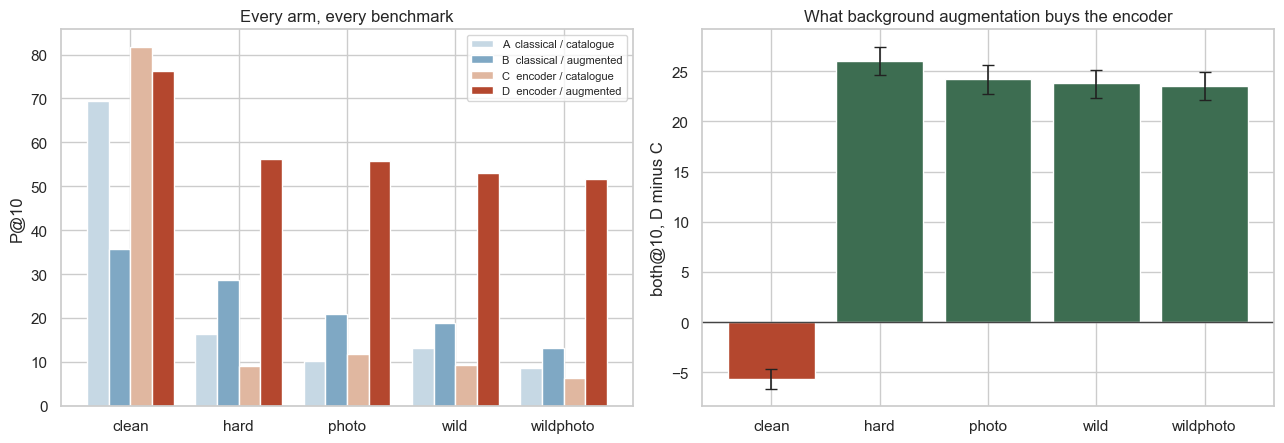

In [33]:
# ============================================
# CELL 24n - What the intervention costs, and what it buys
# ============================================

deltas = significance[significance["metric"] == "both@10"].set_index("benchmark")
deltas = deltas.reindex(BENCH_ORDER)

print("Encoder arms, D (augmented) minus C (catalogue only), both@10")
print("paired over the same %d queries, 95%% bootstrap interval\n"
      % int(deltas["n_queries"].iloc[0]))
for bench, row in deltas.iterrows():
    verdict = "significant" if row["significant"] else "a tie"
    print("  %-10s %+6.2f  [%+.2f, %+.2f]  %s"
          % (bench, row["delta"], row["ci_low"], row["ci_high"], verdict))

in_domain = deltas.loc["clean", "delta"]
out_domain = deltas.loc[["hard", "photo", "wild", "wildphoto"], "delta"].mean()
print("\nAugmentation costs %.2f both@10 in domain and buys %.2f out of it - "
      "a %.1f:1 trade." % (-in_domain, out_domain, out_domain / -in_domain))
print("The selection rule in train_task4_120x160.py already weights out-of-domain")
print("at DEPLOYMENT_WEIGHT = 3.0, which this is the first measurement to justify.")

# The same intervention, both model families. This is the comparison the 2x2
# exists for: a ratio, not a ranking.
print("\nThe same intervention in the two families, P@10:")
for family, clean_arm, aug_arm in (
        ("classical", "A  classical / catalogue", "B  classical / augmented"),
        ("encoder  ", "C  encoder / catalogue", "D  encoder / augmented")):
    cost = p10.loc["clean", aug_arm] - p10.loc["clean", clean_arm]
    gain = p10.loc["photo", aug_arm] - p10.loc["photo", clean_arm]
    print("  %s  clean %+6.2f   photo %+6.2f   ratio %5.2f:1"
          % (family, cost, gain, gain / -cost))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

width = 0.2
x = np.arange(len(BENCH_ORDER))
colours = ["#c6d8e4", "#7fa8c4", "#e0b7a0", "#b4472e"]
for offset, (arm, colour) in enumerate(zip(p10.columns, colours)):
    axes[0].bar(x + (offset - 1.5) * width, p10[arm].to_numpy(), width,
                label=arm, color=colour)
axes[0].set_xticks(x)
axes[0].set_xticklabels(BENCH_ORDER)
axes[0].set_ylabel("P@10")
axes[0].set_title("Every arm, every benchmark")
axes[0].legend(fontsize=8, loc="upper right")

axes[1].axhline(0, color="#444444", linewidth=1)
axes[1].bar(BENCH_ORDER, deltas["delta"].to_numpy(),
            color=["#b4472e" if v < 0 else "#3d6d51" for v in deltas["delta"]])
axes[1].errorbar(BENCH_ORDER, deltas["delta"].to_numpy(),
                 yerr=[deltas["delta"] - deltas["ci_low"],
                       deltas["ci_high"] - deltas["delta"]],
                 fmt="none", ecolor="#222222", capsize=4, linewidth=1.2)
axes[1].set_ylabel("both@10, D minus C")
axes[1].set_title("What background augmentation buys the encoder")

plt.tight_layout()
plt.show()


In [34]:
# ============================================
# CELL 24o - Was it the clustering, or the representation?
# ============================================

# Each classical arm was scored twice: an exact full scan over the descriptor,
# and the k-Means routed search. If the two agree, then whatever the arm loses
# it loses in the representation, and the clustering is exonerated.
routing = (classical.pivot_table(index="benchmark", columns=["arm", "index"],
                                 values="P@10")
           .reindex(BENCH_ORDER))
print("P@10, exact search against k-Means routing\n")
print(routing.to_string())

gaps = []
for arm in ("A_classical_clean", "B_classical_bgaug"):
    gaps.extend((routing[(arm, "exact")] - routing[(arm, "kmeans")]).tolist())
widest = max(gaps, key=abs)
print("\nLargest exact-minus-routed gap: %+.2f points, against a +-1.10 floor."
      % widest)
print("Routing costs at most about a point - at the sampling floor, not")
print("free of it - while the arms differ by tens. The representation")
print("is the story.")

# The trade curve for arm B, if the one-view variant has been run. Arm B
# averages the clean frame with `views` composites, so `views` sets how far the
# descriptor is pulled toward the backdrop average.
curve_rows = []
for views in (1, 3):
    path = EVAL_DIR / ("task4_classical_clustering_arms_v%d.csv" % views)
    if not path.exists():
        continue
    frame = pd.read_csv(path)
    frame = frame[(frame["arm"] == "B_classical_bgaug") & (frame["index"] == "exact")]
    for bench in ("clean", "photo"):
        curve_rows.append({"views": views, "benchmark": bench,
                           "P@10": frame.loc[frame["benchmark"] == bench,
                                             "P@10"].iloc[0]})

if curve_rows:
    curve = (pd.DataFrame(curve_rows).pivot(index="views", columns="benchmark",
                                            values="P@10"))
    baseline = classical[(classical["arm"] == "A_classical_clean")
                         & (classical["index"] == "exact")].set_index("benchmark")
    curve.loc[0] = [baseline.loc["clean", "P@10"],
                    baseline.loc["photo", "P@10"]]
    print("\nArm B trade curve - composited views averaged into the descriptor\n")
    print(curve.sort_index().to_string())
    print("\nMore views buys robustness on photographs and spends it on clean "
          "images. There is no setting where the descriptor gets both, which is "
          "what it means for a representation to be entangled with its backdrop.")
else:
    print("\nRun `python scripts/eval_task4_classical_clustering.py --views 1` "
          "for the trade curve.")


P@10, exact search against k-Means routing

arm       A_classical_clean        B_classical_bgaug       
index                 exact kmeans             exact kmeans
benchmark                                                  
clean                 69.31  68.87             35.74  36.20
hard                  16.39  16.05             28.56  29.71
photo                 10.17  10.48             20.93  21.69
wild                  13.17  13.06             18.79  18.35
wildphoto              8.58   8.77             13.13  12.35

Largest exact-minus-routed gap: -1.15 points, against a +-1.10 floor.
Routing costs at most about a point - at the sampling floor, not
free of it - while the arms differ by tens. The representation
is the story.

Arm B trade curve - composited views averaged into the descriptor

benchmark  clean  photo
views                  
0          69.31  10.17
1          49.73  14.49
3          35.74  20.93

More views buys robustness on photographs and spends it on clean images. T

The result is the strongest statement in this notebook about what the data does to the model.

**Arm C is the best model in the project on clean catalogue images and close to the worst on a
photograph.** Trained on the catalogue exactly as it ships, it reaches P@10 81.64 on clean
frames - above the deployed encoder's 76.19 - and 11.84 on a photographic backdrop. The
catalogue's uniformity does not merely fail to generalise; it produces a model that looks
*better* than the deployed one by the academic metric and is useless on an upload. A single
arm cannot show this, which is the argument for having trained the control.

**The intervention now has a price rather than an assumption.** Background augmentation costs
5.62 `both@10` in domain, with a 95% interval of [-6.63, -4.65] that excludes zero, and
returns 23 to 26 points out of domain. Roughly a 4.4:1 trade, and the first measurement that
justifies weighting out-of-domain at 3:1 in the epoch-selection rule.

**The same intervention has opposite value in the two families, and that is the finding.** For
the classical descriptor it is a bad trade - about 34 points of clean P@10 surrendered for 11
on photographs. For the encoder it is overwhelming - about 5 surrendered for 44. So the
improvement is not "augment the data"; it is *augment the data and hold a representation that
can absorb it*. Averaging a hand-built histogram over backdrops buys invariance by destroying
the signal, because in a composite the garment is a minority of the pixels. The network buys
the same invariance by learning what to ignore, and keeps its discrimination.

**Clustering was never the bottleneck.** Exact search and k-Means routing differ by at most
1.15 points on any cell - one is a hair outside the +-1.10 floor, so routing is not quite
free - while the arms themselves differ by tens, and the router scans about 5% of the
catalogue. Whatever the classical arms lose, they lose in the representation. This is the
attribution that clustering the encoder's own embeddings cannot make.

**A detail worth keeping.** On `hard` and `wild`, arm C scores *below* arm A - a network
trained only on clean frames is more background-brittle than a hand-built histogram. Given the
capacity to lean on the white field, it leaned harder.

One seed per arm. The intervals above are paired query-sampling error, not seed variance,
which remains unmeasured for retrieval. The 23-to-44-point gaps are far outside any plausible
seed effect; the 5.62 in-domain cost is the one number a second seed would materially sharpen.

## Part 7: Looking at the results

Retrieval metrics can look healthy while the results are useless to a person, so the output has
to be inspected directly. Successes and failures are both shown - the failures are what the
report should discuss.

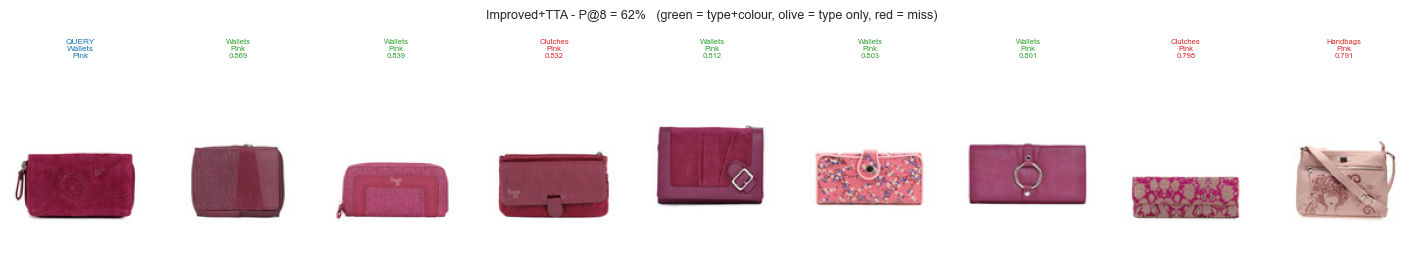

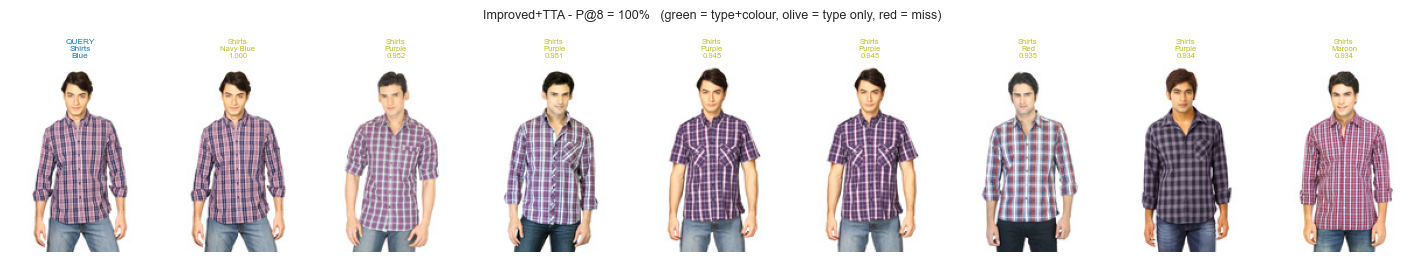

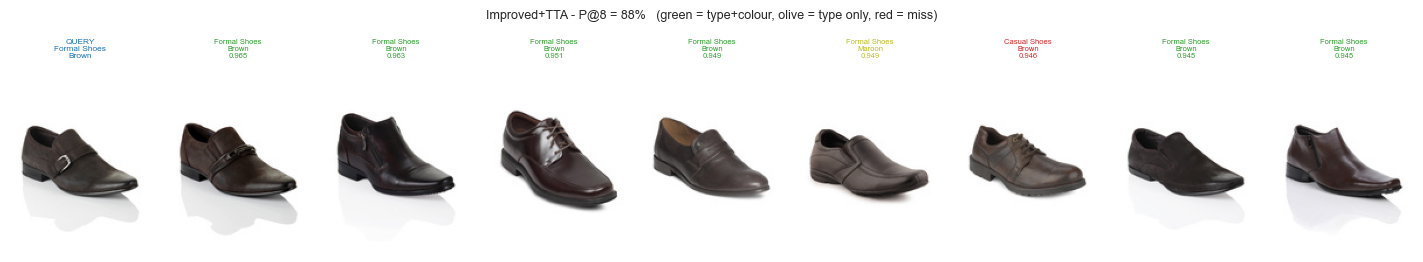

In [35]:
# ============================================
# CELL 25 - Show a query and its Top-K matches
# ============================================

def show_retrieval(method, query_position, k=8, ax_title=True):
    """Display a query and its top-K matches. Works for every index type."""
    index = INDEXES[method]
    vector = np.asarray(EMBEDDINGS[method])[query_position]

    # A CatalogueIndex never contains the query, so nothing needs excluding.
    scores, positions = index.search(vector, k=k)
    scores, positions = scores[0], positions[0]

    fig, axes = plt.subplots(1, k + 1, figsize=(1.6 * (k + 1), 2.8))
    axes[0].imshow(np.asarray(IMAGES[query_position]))
    axes[0].axis("off")
    axes[0].set_title(f"QUERY\n{article[query_position]}\n{colour_values[query_position]}",
                      fontsize=6, color="tab:blue")

    for slot, (position, score) in enumerate(zip(positions, scores), start=1):
        axes[slot].imshow(np.asarray(IMAGES[position]))
        axes[slot].axis("off")
        type_hit = article[position] == article[query_position]
        colour_hit = colour_values[position] == colour_values[query_position]
        colour = ("tab:green" if type_hit and colour_hit else
                  "tab:olive" if type_hit else "tab:red")
        axes[slot].set_title(f"{article[position]}\n{colour_values[position]}\n{score:.3f}",
                             fontsize=5.5, color=colour)
    if ax_title:
        precision = np.mean([article[p] == article[query_position] for p in positions])
        fig.suptitle(f"{method} - P@{k} = {precision * 100:.0f}%   "
                     f"(green = type+colour, olive = type only, red = miss)", fontsize=9)
    plt.tight_layout(); plt.show()


# Queries are drawn from the HELD-OUT set: images the encoder has never seen.
set_seed()
demo_queries = np.random.choice(HELDOUT_QUERIES, 3, replace=False)
for position in demo_queries:
    show_retrieval(BEST_METHOD, position, k=8)

Unseen query: Wallets / Pink
Baggit Women Pink Wallet



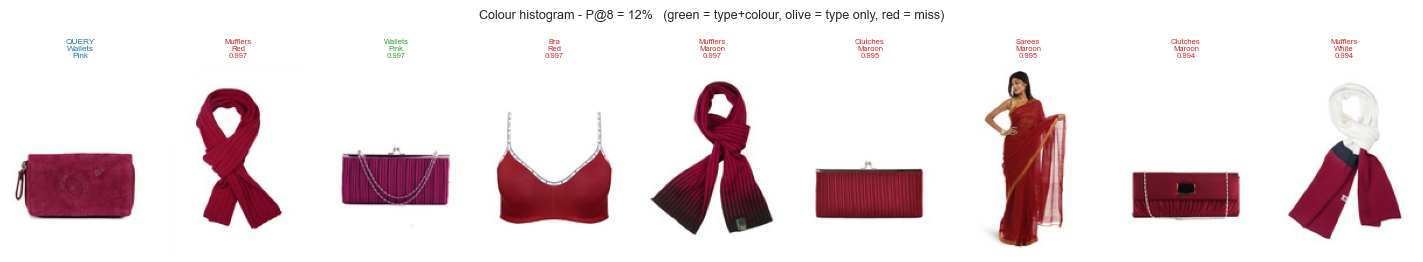

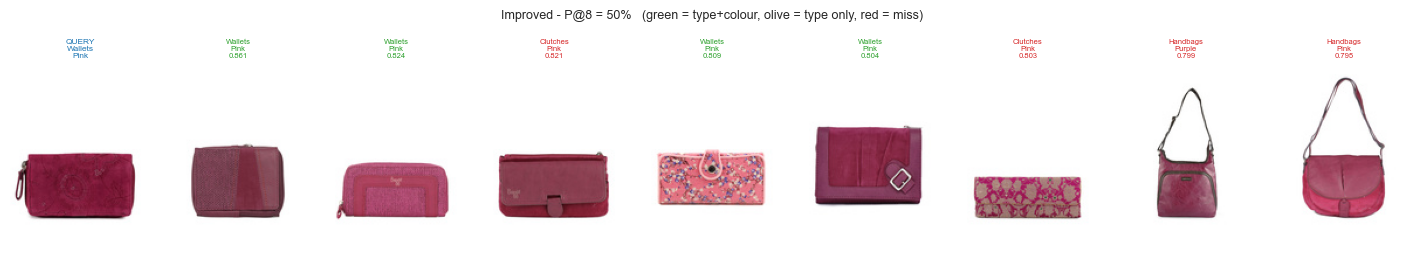

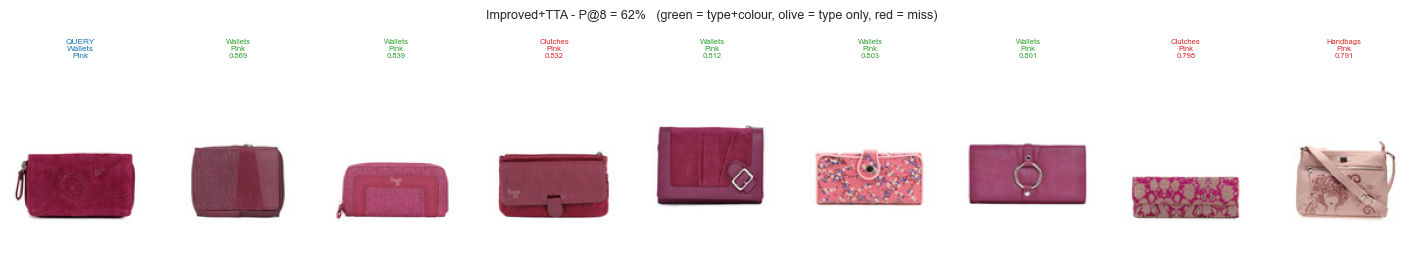

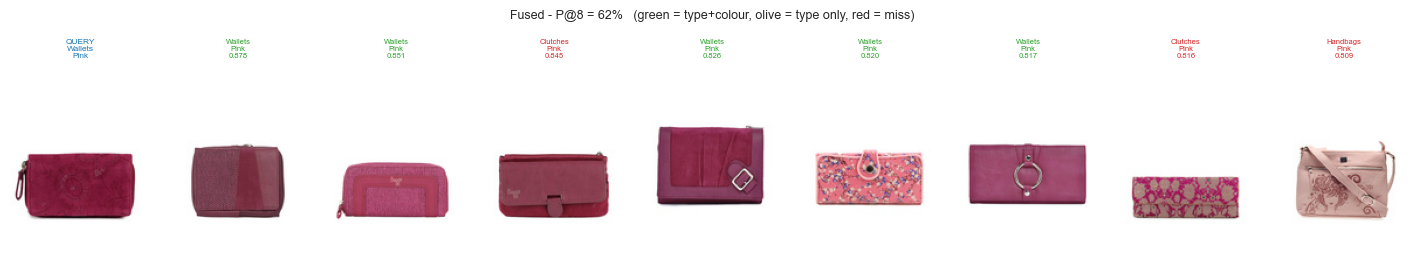

In [36]:
# ============================================
# CELL 26 - One query, the surviving representations side by side
# ============================================

comparison_query = demo_queries[0]
print(f"Unseen query: {article[comparison_query]} / {colour_values[comparison_query]}")
print(f"{gallery.loc[comparison_query, 'productDisplayName']}\n")

# The colour histogram is shown beside the encoder because it is the clearest
# illustration of what the learned model adds: it matches the shade and misses
# the garment.
for method in ["Colour histogram", "Improved", "Improved+TTA", "Fused"]:
    if method in INDEXES:
        show_retrieval(method, comparison_query, k=8)


Worst unseen queries for Improved+TTA:


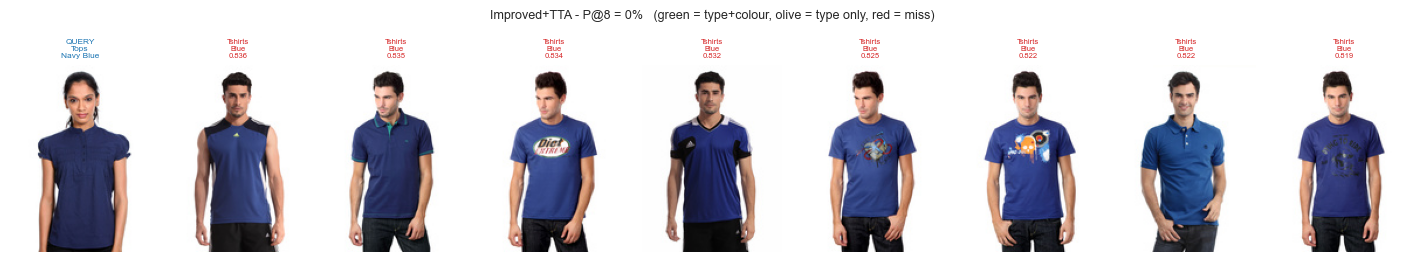

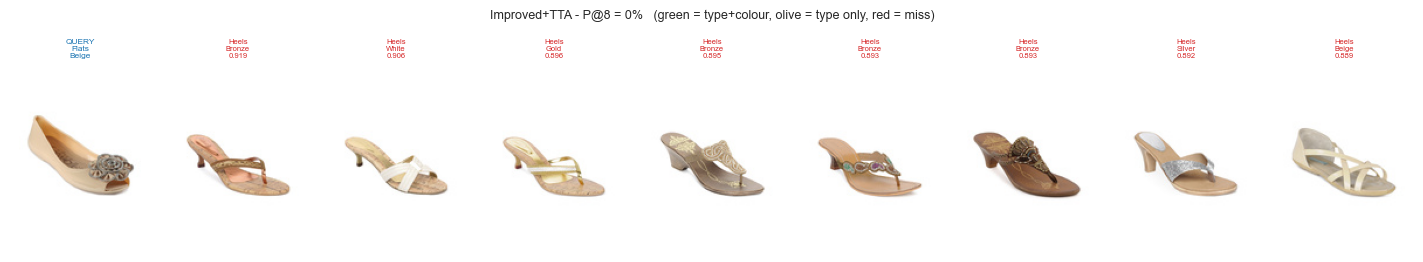

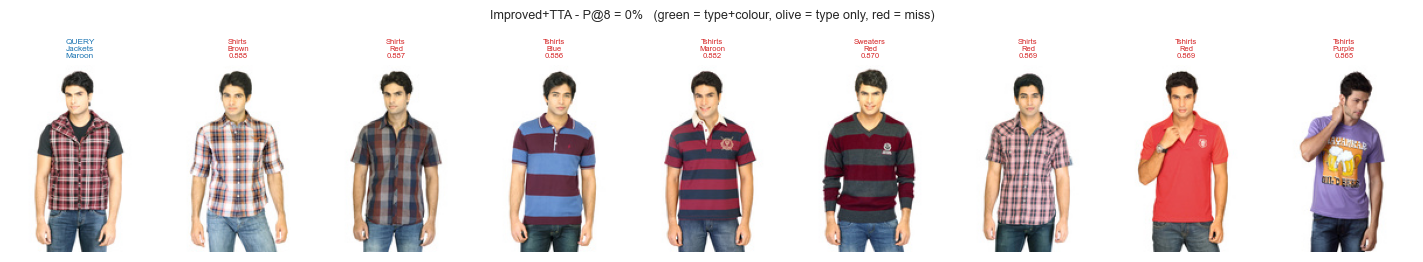

Typical causes: visually ambiguous silhouettes (tops vs tunics vs kurtis),
items photographed on a model rather than flat, and product types with few
close neighbours in the catalogue.


In [37]:
# ============================================
# CELL 27 - Failure cases on unseen queries
# ============================================

_, ranked_best = evaluate_deployment(INDEXES[BEST_METHOD], EMBEDDINGS[BEST_METHOD],
                                     label="_tmp")
DEPLOY_RESULTS.pop("_tmp", None)

k = CONFIG["top_k"]
scores = np.array([
    np.mean([article[p] == article[q] for p in ranked_best[i][:k]])
    for i, q in enumerate(HELDOUT_QUERIES)
])
worst_idx = np.argsort(scores)[:3]

print(f"Worst unseen queries for {BEST_METHOD}:")
for i in worst_idx:
    show_retrieval(BEST_METHOD, int(HELDOUT_QUERIES[i]), k=8)

print("Typical causes: visually ambiguous silhouettes (tops vs tunics vs kurtis),")
print("items photographed on a model rather than flat, and product types with few")
print("close neighbours in the catalogue.")

### Part 7b: Is the embedding space actually organised?

t-SNE projects the high-dimensional embedding to 2D. If items of the same type form clusters,
the space has structure that nearest-neighbour search can exploit; if the projection is uniform
soup, good metrics would be suspicious.

t-SNE distances are not meaningful - only the grouping is. It is fitted on a sample for speed.

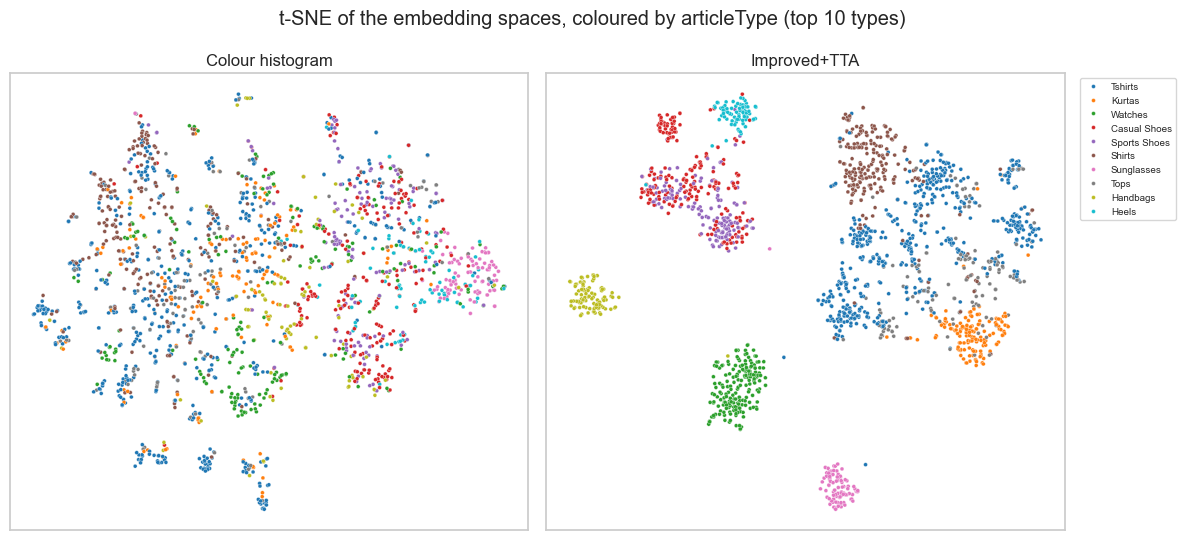

In [38]:
# ============================================
# CELL 28 - t-SNE map of the embedding space
# ============================================

from sklearn.manifold import TSNE

TSNE_SAMPLE = 3000
set_seed()
tsne_positions = np.random.choice(len(gallery), TSNE_SAMPLE, replace=False)
top_types = gallery["articleType"].value_counts().head(10).index
mask = gallery.loc[tsne_positions, "articleType"].isin(top_types).to_numpy()
tsne_positions = tsne_positions[mask]

# The colour histogram is projected beside the encoder so the two failure modes
# are visible together: the histogram organises by shade and mixes garments, the
# encoder separates garments.
show_methods = [m for m in ["Colour histogram", "Improved+TTA"] if m in EMBEDDINGS]

fig, axes = plt.subplots(1, len(show_methods), figsize=(6 * len(show_methods), 5.5),
                         squeeze=False)
for ax, name in zip(axes[0], show_methods):
    vectors = np.asarray(EMBEDDINGS[name])[tsne_positions]
    projected = TSNE(n_components=2, perplexity=30, init="pca",
                     random_state=RANDOM_STATE).fit_transform(vectors)
    frame = pd.DataFrame({
        "x": projected[:, 0], "y": projected[:, 1],
        "articleType": gallery.loc[tsne_positions, "articleType"].to_numpy(),
    })
    sns.scatterplot(data=frame, x="x", y="y", hue="articleType", s=8, ax=ax,
                    legend=(name == show_methods[-1]), palette="tab10")
    ax.set_title(name); ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticks([]); ax.set_yticks([])
axes[0][-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.suptitle("t-SNE of the embedding spaces, coloured by articleType (top 10 types)")
plt.tight_layout(); plt.show()


## Part 8: The realistic use case - querying with unseen images

Everything above uses gallery images as queries. The real system receives a **new** photograph
and searches the existing catalogue. The unlabelled `images_test` set provides exactly that:
5,829 images the model has never seen.

No accuracy can be computed here (no labels), so this is a qualitative demonstration plus a
latency measurement for the deployment discussion.

Unseen images available as queries: 5829
Search latency: 2.33 ms per query over 32,944 catalogue items



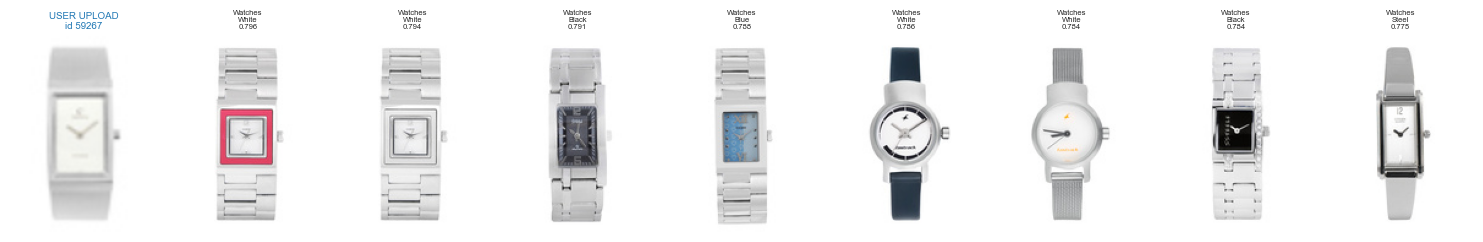

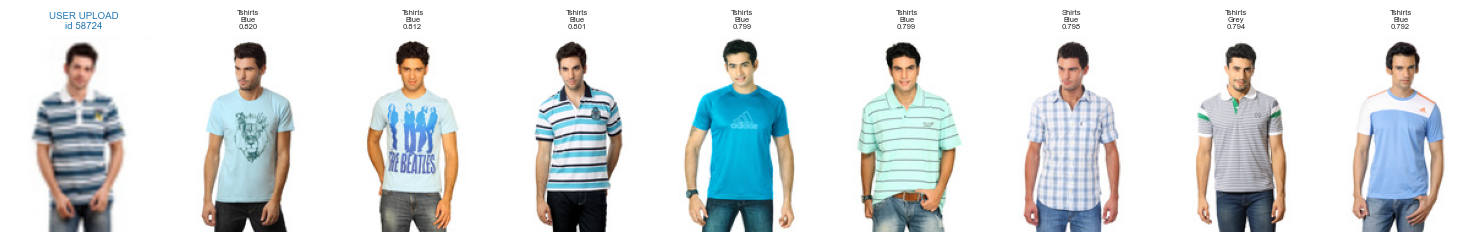

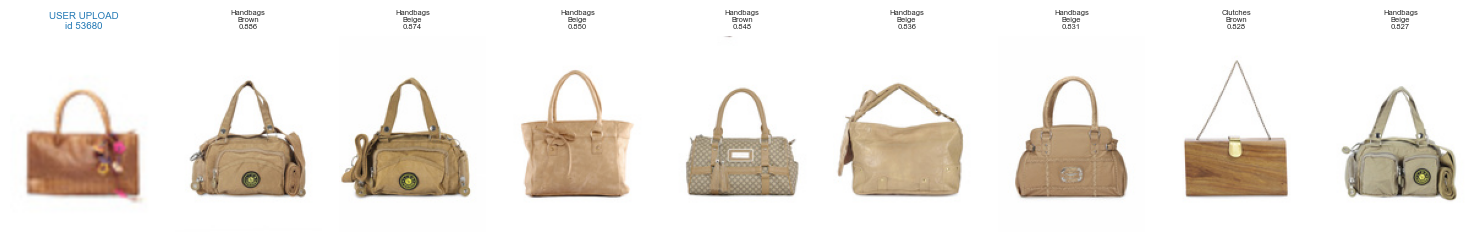

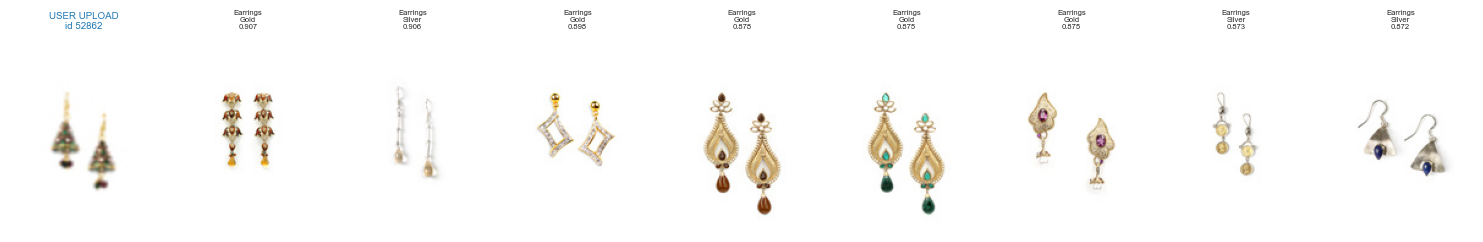

In [39]:
# ============================================
# CELL 29 - The real use case: a photo that is not in the dataset
# ============================================

test_meta = pd.read_csv(PREDICTION_METADATA)
print("Unseen images available as queries:", len(test_meta))


def embed_new_images(paths, method=None, tta=None):
    """Embed images that are NOT in the gallery - the deployment path.

    Uses exactly the pipeline the gallery embeddings were built with, so a
    user's upload is treated identically to a catalogue item.
    """
    method = method or BEST_METHOD
    tta = CONFIG["use_tta"] if tta is None else tta
    arrays = np.stack([load_image_array(p) for p in paths])

    tensor = torch.from_numpy(arrays.astype(np.float32).transpose(0, 3, 1, 2) / 255.0)
    tensor = ((tensor - MEAN_T) / STD_T).to(DEVICE)

    with torch.no_grad():
        if method.startswith("Improved") or method == "Fused":
            vectors = improved_model.embed(tensor)
            if tta or "TTA" in method or method == "Fused":
                mirrored = improved_model.embed(torch.flip(tensor, dims=[3]))
                vectors = F.normalize(vectors + mirrored, p=2, dim=1)
            learned_part = vectors.float().cpu().numpy()

            if "rerank" in method:
                # [learned | colour] - RerankIndex splits this internally
                colour_part = colour_histogram(arrays)
                return np.hstack([l2(learned_part), l2(colour_part)])
            if method == "Fused":
                colour_part = colour_histogram(arrays)
                return np.hstack([l2(learned_part) * (1 - BEST_WEIGHT),
                                  l2(colour_part) * BEST_WEIGHT])
            return learned_part

    raise ValueError(f"Unknown method {method}")


set_seed()
sample_tests = test_meta.sample(4, random_state=RANDOM_STATE)
query_vectors = embed_new_images(sample_tests["image_path"].tolist(), BEST_METHOD)

start = time.time()
scores, positions = INDEXES[BEST_METHOD].search(query_vectors, k=8)
elapsed = (time.time() - start) / len(query_vectors) * 1000
print(f"Search latency: {elapsed:.2f} ms per query over "
      f"{len(INDEXES[BEST_METHOD]):,} catalogue items\n")

for row_index, (_, test_row) in enumerate(sample_tests.iterrows()):
    fig, axes = plt.subplots(1, 9, figsize=(15, 2.9))
    axes[0].imshow(load_image_array(test_row["image_path"]))
    axes[0].axis("off")
    axes[0].set_title(f"USER UPLOAD\nid {test_row['id']}", fontsize=7, color="tab:blue")
    for slot in range(8):
        position = positions[row_index, slot]
        axes[slot + 1].imshow(np.asarray(IMAGES[position]))
        axes[slot + 1].axis("off")
        axes[slot + 1].set_title(f"{article[position]}\n{colour_values[position]}\n"
                                 f"{scores[row_index, slot]:.3f}", fontsize=5.5)
    plt.tight_layout(); plt.show()

### Part 8b: Both encoders, both kinds of test image

Part 6b graded the two encoders on *synthetic* out-of-domain frames - catalogue items cut
out and pasted onto Places365 scenes. That is a proxy, and a flattering one: the garment
underneath is still centred, still studio-lit, still the same photograph.

`A2_FashionDataset/input_images/` holds 31 pictures that are not a proxy. Phone photographs,
web screenshots, several garments in one frame, a few things that are not clothing at all.
Running both encoders over both kinds of image completes the table:

|                     | catalogue test set | outside set (31 real photos) |
|---------------------|--------------------|------------------------------|
| encoder, white only | labelled, P@10     | unlabelled - see below       |
| encoder, + backgrounds | labelled, P@10  | unlabelled - see below       |

**What the outside column can and cannot say.** `input_images_labels.csv` is an empty
template: 31 rows, every `articleType` blank. Without a ground-truth type there is no P@10 to
compute on these photographs, and inventing one would be worse than not having it. So the
outside column reports what is honestly available without labels - how similar the returned
items are, how far that falls below the same encoder's similarity on catalogue-style photos,
and, most usefully, **how much the two encoders agree with each other**. Agreement needs no
labels at all and answers the question directly: did the training data change the answer?

Fill the label sheet in and the cell below adds real `P@1`/`P@10` by itself.

In [40]:
# ============================================
# CELL 29b - Both encoders, both kinds of test image
# ============================================

from src.evaluation import real_photo_arms as rpa

# Both arms are indexed over the SAME 38,571-row training cache rather than the
# served index, which covers 38,612. Mixing the two would compare the arms over
# different catalogues; the encoder is the variable here, so the catalogue is
# held fixed. Building the two indexes takes a couple of minutes.
arm_gallery = pd.read_csv(GALLERY_CSV)
arm_images = np.load(CACHE_X, mmap_mode="r")

arm_engines = {}
for arm_name, arm_file in rpa.ARMS.items():
    checkpoint_path = TRAINED_DIR / arm_file
    if not checkpoint_path.exists():
        print("missing", arm_file, "- run:")
        print("    python -m src.training.train_task4_120x160 "
              "--backgrounds none --seed 42")
        continue
    arm_engines[arm_name] = rpa.build_engine(checkpoint_path, arm_gallery, arm_images)
    print("%-20s index %s  background_augmented=%s"
          % (arm_name, arm_engines[arm_name].index.shape,
             arm_engines[arm_name].manifest["background_augmented"]))

real_paths = rpa.real_photo_paths(PROJECT_DIR)
real_labels = rpa.real_photo_labels(PROJECT_DIR)
print("\n" + rpa.describe_label_state(real_labels, real_paths))

# Catalogue-style photographs, so the similarity on real uploads is readable
# against an in-domain number instead of standing on its own.
reference_paths = sorted(TEST_IMAGE_DIR.iterdir())[:60] if TEST_IMAGE_DIR.exists() else None

arm_summary, arm_per_photo = rpa.score_arms(
    arm_engines, real_paths, labels=real_labels, reference=reference_paths)

print("\n--- outside set: 31 real photographs ---\n")
print(arm_summary.to_string(index=False))

catalogue_column = rpa.catalogue_test_scores(PROJECT_DIR)
if catalogue_column is not None:
    print("\n--- catalogue test set, for the other half of the table ---\n")
    print(catalogue_column[catalogue_column["benchmark"].isin(["clean", "photo"])]
          [["arm", "benchmark", "P@10", "both@10"]].to_string(index=False))


white only           index (38571, 128)  background_augmented=False
white + backgrounds  index (38571, 128)  background_augmented=True

23 of 31 real photographs carry a catalogue articleType, so P@1 and P@10 below are measured on those. The rest are marked n/a/none: not one catalogue garment, and excluded rather than counted as misses.

--- outside set: 31 real photographs ---

                arm  images  top1 similarity  top10 similarity  ingestion declined  top1 on catalogue photos  similarity drop  top10 overlap with other arm  same top-1 as other arm   P@1  P@10  labelled
         white only      31           0.6702            0.6383                   1                    0.7764           0.1062                        0.0645                   0.0323  8.70  8.70      23.0
white + backgrounds      31           0.7250            0.6812                   1                    0.7963           0.0713                        0.0645                   0.0323 26.09 23.04      23.0

--- cata

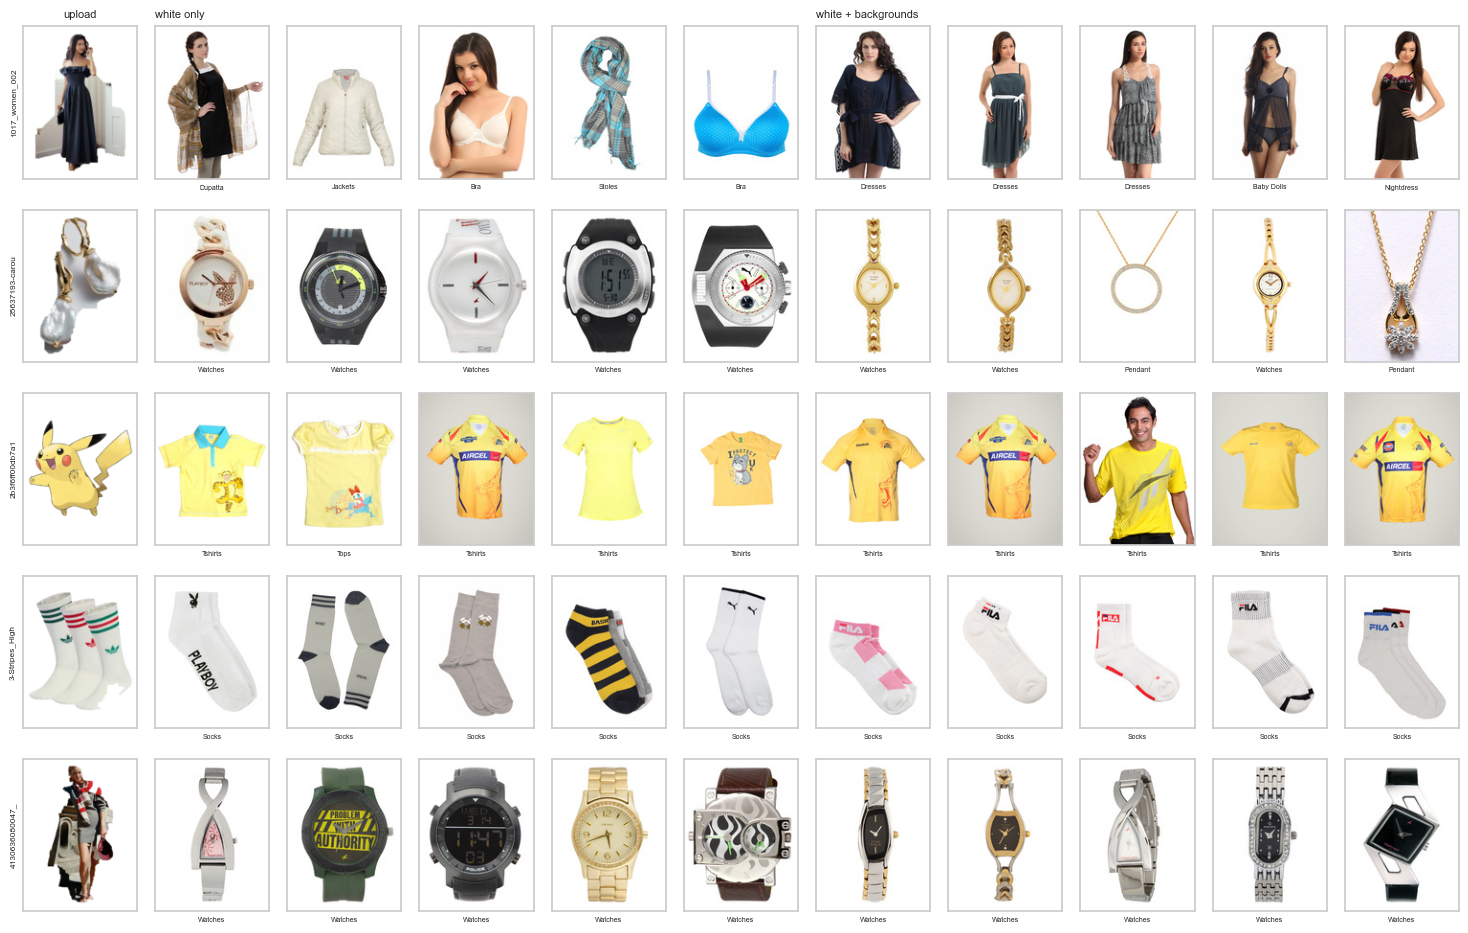

top-10 overlap between the two arms, per photograph:
                                                                 file  top10 overlap  same top-1
         1017_women_0023_a36fe2486db54e83b62813b56147a042_master.webp            0.0       False
                             25637193-carousel-block-earrings-v1.webp            0.1       False
                         2b3f6ff00db7a1efae21d85cfb8995eaff2da8d8.png            0.1       False
3-Stripes_High_Crew_Socks_3_Pairs_White_KD8239_01_01_00_standard.avif            0.0       False
                                           4130636080047_004_b14.webp            0.0       False


In [41]:
# ============================================
# CELL 29c - The same photograph through both encoders
# ============================================

# With no labels, the eye is the evaluator. Each row is one real upload: the
# query, then what the white-only encoder returns, then what the
# background-trained one returns for the identical picture.
from src.data.user_image import load_user_image

N_SHOW, K_SHOW = 5, 5
if len(arm_engines) == 2 and len(real_paths):
    shown = real_paths[:N_SHOW]
    names = list(arm_engines)
    fig, axes = plt.subplots(len(shown), 1 + 2 * K_SHOW,
                             figsize=(1.35 * (1 + 2 * K_SHOW), 1.9 * len(shown)))
    axes = np.atleast_2d(axes)

    for row, path in enumerate(shown):
        frame = load_user_image(path, tuple(arm_engines[names[0]].size), mode="nobg")
        axes[row, 0].imshow(frame)
        axes[row, 0].set_ylabel(path.name[:14], fontsize=6)
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
        if row == 0:
            axes[row, 0].set_title("upload", fontsize=8)

        for side, name in enumerate(names):
            vector = arm_engines[name].embed([path], mode="nobg")
            top = np.argsort(-(vector @ arm_engines[name].index.T)[0])[:K_SHOW]
            for column, position in enumerate(top):
                axis = axes[row, 1 + side * K_SHOW + column]
                axis.imshow(np.asarray(arm_images[position]))
                axis.set_xticks([]); axis.set_yticks([])
                axis.set_xlabel(str(arm_gallery.loc[position, "articleType"])[:12],
                                fontsize=5)
                if row == 0 and column == 0:
                    axis.set_title(name, fontsize=8, loc="left")

    plt.tight_layout()
    plt.show()

    print("top-10 overlap between the two arms, per photograph:")
    print(arm_per_photo.head(N_SHOW).to_string(index=False))


**The two encoders almost never return the same thing for a real photograph.** Their top-10
sets overlap by **6.5%**, and they pick the same single best match for **1 of the 31** uploads.
Whatever else is true, the choice of training data does not nudge the result on a real photo -
it replaces it.

**The background-trained encoder is markedly more confident, and confident in a way that
tracks the synthetic benchmark.** Its mean top-1 similarity on the real uploads is 0.725
against 0.670, and - the more meaningful figure - it falls only **0.072** below its own
similarity on catalogue-style photographs, where the white-only encoder falls **0.106**. The
white-only model is further out of its depth on a real photo, by its own measure.

**Confidence is not correctness, and without labels this section cannot claim it is.** What
makes the inference safe is the other half of the table: on backgrounded images we *do* have
ground truth, and there the white-only encoder scores P@10 11.84 against 55.78. A model that
is demonstrably broken on backgrounded catalogue items, disagrees with the working model on
94% of real-photo results, and is less confident on every one of them, is not the model to
trust on an upload. That is an argument built from three measurements rather than an assumption
about what similarity means.

One photograph in 31 defeated the ingestion path entirely - no plausible foreground mask, so it
fell back to a centre crop. That is a property of the picture, not of either encoder; both saw
the identical frame.

## Part 9: Saving the search index

Saved as plain `.npy` plus a small JSON manifest so `app/backend/main.py` can load and serve it
without importing this notebook.

In [42]:
# ============================================
# CELL 30 - Persist this notebook's evaluation artefacts
# ============================================

# This cell writes what the notebook MEASURED. It deliberately does not write
# what the application SERVES.
#
# It used to do both, and the two want different things. Evaluation needs a
# catalogue-only index - the held-out products are excluded, which is the whole
# point of the protocol. The application needs every row the shop stocks, so a
# customer can find anything. Writing the evaluation index and its 32,944-row
# metadata over `gallery_metadata.csv` left 5,600 held-out items plus the 41
# conflicting-label rows unreachable by search, and the manifest pointed at it.
#
# Promotion is one command, and it rebuilds the index, the metadata, the ids and
# the manifest together so they cannot drift apart:
#
#     python scripts/promote_task4_encoder.py \
#         --encoder artifacts/task4_120x160/task4_encoder_mixed_seed42.pt

catalogue_vectors = np.asarray(EMBEDDINGS[BEST_METHOD])[CATALOGUE_POS].astype(np.float32)
catalogue_ids = gallery["id"].to_numpy()[CATALOGUE_POS]

safe_name = re.sub(r"[^a-z0-9]+", "_", BEST_METHOD.lower()).strip("_")
INDEX_PATH = ARTIFACT_DIR / f"search_index_{safe_name}.npy"

if INDEX_PATH.exists():
    INDEX_PATH.unlink()
    print("Replaced existing index:", INDEX_PATH.name)
np.save(INDEX_PATH, catalogue_vectors)

assert catalogue_vectors.shape[0] == len(catalogue_ids)
assert catalogue_vectors.shape[0] == len(CATALOGUE_POS)

# `_per_query_*` entries are 2,000-element arrays kept for the significance
# tests, not scores. `float()` on one raises "only length-1 arrays can be
# converted to Python scalars", so the leading underscore is the filter.
deployment_metrics = {k: round(float(v), 4)
                      for k, v in DEPLOY_RESULTS[BEST_METHOD].items()
                      if not k.startswith("_")}

evaluation = {
    "best_method": BEST_METHOD,
    "evaluation_index_file": INDEX_PATH.name,
    "evaluation_catalogue_size": int(len(CATALOGUE_POS)),
    "held_out_products": int(len(np.unique(PROTOCOL.product_key[PROTOCOL.heldout_pos]))),
    "held_out_images": int(len(HELDOUT_POS)),
    "embedding_dim": int(catalogue_vectors.shape[1]),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "fusion_colour_weight": BEST_WEIGHT,
    "use_tta": CONFIG["use_tta"],
    "uses_reranking": "rerank" in BEST_METHOD,
    "rerank_alpha": BEST_ALPHA if "rerank" in BEST_METHOD else None,
    "deployment_metrics": deployment_metrics,
    "note": ("Measured by 05_task4_triplet_encoder.ipynb against a catalogue-only "
             "index. The SERVED artefacts are written by "
             "scripts/promote_task4_encoder.py and cover the whole catalogue."),
}
with open(ARTIFACT_DIR / "task4_evaluation.json", "w") as f:
    json.dump(evaluation, f, indent=2)

standard_table.to_csv(ARTIFACT_DIR / "retrieval_standard.csv", index=False)
strict_table.to_csv(ARTIFACT_DIR / "retrieval_strict.csv", index=False)
by_class.to_csv(ARTIFACT_DIR / "per_class_retrieval.csv")

print(f"\nEvaluation index written: {INDEX_PATH.name}  "
      f"({catalogue_vectors.shape[0]} x {catalogue_vectors.shape[1]}, "
      f"{INDEX_PATH.stat().st_size / 1e6:.2f} MB)")
print("Evaluation summary      : task4_evaluation.json")

served = ARTIFACT_DIR / "search_manifest.json"
if served.exists():
    with open(served) as handle:
        live = json.load(handle)
    print(f"\nServed manifest is untouched: {live['best_method']} at "
          f"{live['image_size_pil']}, {live['catalogue_size']:,} rows.")
    if live.get("catalogue_size") != len(gallery):
        print("  (it covers the full catalogue; this notebook measures the "
              f"{len(CATALOGUE_POS):,}-row evaluation split)")


Replaced existing index: search_index_improved_tta.npy

Evaluation index written: search_index_improved_tta.npy  (32944 x 128, 16.87 MB)
Evaluation summary      : task4_evaluation.json

Served manifest is untouched: Improved+TTA+places365 at [120, 160], 38,612 rows.
  (it covers the full catalogue; this notebook measures the 32,944-row evaluation split)


In [43]:
# ============================================
# CELL 31 - Standalone search function for the application
# ============================================

def load_search_engine(artifact_dir=ARTIFACT_DIR):
    """Load the saved index without this notebook. Used by app/backend/main.py.

    Rebuilds whichever search behaviour was selected: a plain cosine index, or
    the shortlist-then-re-order variant. Loading a re-ranked index as a plain one
    would silently change the scoring, because a cosine over [learned | colour]
    is an equal-weight fusion rather than the tuned blend.
    """
    with open(artifact_dir / "search_manifest.json") as f:
        manifest = json.load(f)
    vectors = np.load(artifact_dir / manifest["index_file"])
    meta = pd.read_csv(artifact_dir / "gallery_metadata.csv")

    assert vectors.shape[1] == manifest["embedding_dim"], (
        f"Manifest says {manifest['embedding_dim']} dimensions but the array has "
        f"{vectors.shape[1]}"
    )

    if manifest.get("uses_reranking") and manifest.get("rerank_alpha", 1.0) < 1.0:
        split = manifest["learned_dim"]
        # The saved arrays are already catalogue-only, so the index must not
        # subset them again - identity positions.
        index = RerankIndex(vectors[:, :split], vectors[:, split:],
                            manifest["rerank_alpha"], name=manifest["best_method"],
                            pool=manifest.get("rerank_pool", 100),
                            catalogue=np.arange(len(vectors)))
    else:
        index = VisualSearchIndex(vectors, name=manifest["best_method"])
    return index, meta, manifest


def search_by_path(image_path, k=10):
    """An image file in, a ranked table of similar catalogue products out."""
    vector = embed_new_images([image_path], BEST_METHOD)
    scores, positions = INDEXES[BEST_METHOD].search(vector, k=k)
    results = gallery.iloc[positions[0]][
        ["id", "articleType", "baseColour", "gender", "usage", "productDisplayName"]
    ].copy()
    results.insert(0, "rank", np.arange(1, len(results) + 1))
    results["similarity"] = scores[0].round(4)
    return results.reset_index(drop=True)


demo_path = test_meta.iloc[0]["image_path"]
print("Query image (not in the dataset):", Path(demo_path).name)
display(search_by_path(demo_path, k=10))

reloaded_index, reloaded_meta, reloaded_manifest = load_search_engine()
print("\nReloaded:", reloaded_manifest["best_method"],
      "| catalogue vectors:", len(reloaded_index), "| dim:", reloaded_index.dim)

Query image (not in the dataset): 52003.jpg


,rank,id,articleType,baseColour,gender,usage,productDisplayName,similarity
0,1,34310,Stoles,Black,Women,Ethnic,Fabindia Women Black Silk & Wool Stole,0.6613
1,2,12142,Kurtas,Purple,Women,Ethnic,Aurelia Women Solid Purple Kurtas,0.6608
2,3,43518,Tops,Navy Blue,Women,Casual,French Connection Women Navy Blue Printed Top,0.6450
3,4,35023,Stoles,Purple,Women,Casual,Fabindia Women Purple & Red Chanderi Hand Prin...,0.6423
4,5,43923,Tops,Blue,Women,Casual,Femella Women Blue Top,0.6415
5,6,19646,Tops,Black,Women,Casual,United Colors of Benetton Women Solid Black Top,0.6413
6,7,7693,Tshirts,Purple,Women,Casual,Urban Yoga Women's Fly Purple T-shirt,0.6378
7,8,14721,Shirts,Purple,Women,Casual,Scullers For Her Women Casual Shirt Purple Shirts,0.6300
8,9,50352,Kurtas,Navy Blue,Women,Ethnic,Aurelia Women Navy Blue Kurta,0.6209
9,10,3441,Tshirts,Blue,Women,Sports,Delhi Daredevils Womens Match Jersey,0.6143



Reloaded: Improved+TTA+places365 | catalogue vectors: 38612 | dim: 128


## Part 10: Summary for the report

In [44]:
# ============================================
# CELL 32 - Consolidated results
# ============================================

k = CONFIG["top_k"]
random_floor = (class_counts / len(gallery) * class_counts).sum() / len(gallery) * 100
best = DEPLOY_RESULTS[BEST_METHOD]

summary_report = {
    "gallery_size": len(gallery),
    "catalogue_size": int(len(CATALOGUE_POS)),
    "held_out_query_images": int(len(HELDOUT_QUERIES)),
    "relevance_attribute": RELEVANCE_COL,
    "methods_compared": list(DEPLOY_RESULTS),
    "best_method": BEST_METHOD,
    "embedding_dim": int(best["dim"]),
    f"random_baseline_P@{k}": round(random_floor, 2),

    # deployment protocol: unseen queries, catalogue-only index
    f"P@{k}_unseen": round(best[f"P@{k}"] * 100, 2),
    f"mAP@{k}_unseen": round(best[f"AP@{k}"] * 100, 2),
    f"nDCG@{k}_unseen": round(best[f"nDCG@{k}"] * 100, 2),
    "R_precision_unseen": round(best["R-precision"] * 100, 2),
    "colour@10_unseen": round(best["colour@10"] * 100, 2),
    "both@10_unseen": round(best["both@10"] * 100, 2),

    # the earlier, optimistic protocol - kept for the comparison in the report
    "P@10_gallery_queries_old_protocol": round(
        RESULTS[BEST_METHOD]["strict"]["P@10"] * 100, 2)
        if BEST_METHOD in RESULTS else None,
    "control_attribute": CONTROL_COL,
    "control_winner": control_winner,

    "ms_per_query": round(best["ms_per_query"], 2),
    "index_size_mb": round(INDEX_PATH.stat().st_size / 1e6, 2),
    "index_dim_on_disk": int(np.load(INDEX_PATH, mmap_mode="r").shape[1]),
    "fusion_colour_weight": BEST_WEIGHT,
    "rerank_alpha": BEST_ALPHA,
}
display(pd.Series(summary_report).to_frame("Value"))

with open(ARTIFACT_DIR / "task4_summary.json", "w") as f:
    json.dump(summary_report, f, indent=2, default=str)
print("Saved", ARTIFACT_DIR / "task4_summary.json")

,Value
gallery_size,38571
catalogue_size,32944
held_out_query_images,2000
relevance_attribute,articleType
methods_compared,"[Colour histogram, Improved, Improved+TTA, Fus..."
best_method,Improved+TTA
embedding_dim,128
random_baseline_P@10,5.91
P@10_unseen,76.19
mAP@10_unseen,70.38


Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task4\task4_summary.json


### Points to carry into the written report

* **Problem framing.** Retrieval has no fixed label set, so the system learns an embedding and
  ranks by cosine similarity. The encoder is compared against a non-learned colour
  baseline under one evaluation protocol, with the random-retrieval floor as the reference.
* **Evaluation design.** Relevance is a metadata proxy (`articleType`). Queries are sampled
  **stratified by class**, so the headline figure is not dominated by whichever types happen to
  be most common.
* **Circularity, and the control for it.** The Triplet model was trained on `articleType` and
  then scored on it, which is why its 92.33 is not the result it appears to be. The encoder
  that replaced it carries auxiliary `articleType` and `baseColour` heads, so both scored
  attributes are trained attributes and the same objection applies to it. `subCategory` is
  therefore scored as a control: no loss in this notebook has ever seen it.
* **Metric choice.** Recall@10 is near-zero by construction when a class has thousands of
  members, so **R-precision** (precision at K = number of relevant items) is reported as the
  size-invariant alternative. nDCG is computed against the *best achievable* ranking for each
  query, not against a hypothetical ten perfect matches, which would penalise rare classes
  unfairly.
* **`both@10` is the metric that separates the methods.** A triplet loss on `articleType`
  alone ranks type well and colour badly, because nothing in that objective asks about colour;
  the auxiliary `baseColour` head is what fixes it. Report `P@10` and `both@10` together or the
  comparison misleads.
* **Three protocols, three different numbers for one encoder (Part 6).** Gallery queries
  with standard exclusion, gallery queries with strict exclusion, and unseen products against a
  catalogue-only index. The first two describe the catalogue's duplicate rate; only the third
  describes the product.
* **Difficulty is driven by visual confusability, not rarity.** Tops (1,614 items) scores far
  below Belts (795) and Watches (2,252). Tops, tunics, kurtis and t-shirts share a silhouette
  at 60x80, while a watch resembles nothing else in the catalogue. The Spearman correlation
  between class size and P@10 quantifies this.
* **Reuse across tasks failed, and the failure is informative.** The Task 3 classifier doubles
  as a feature extractor at zero training cost, but it finished **last** - it was trained to
  predict gender and usage, which do not require separating a shirt from a t-shirt, so it
  learned to discard exactly the distinctions retrieval needs.
* **Deployment.** Exact search over 38,600 vectors runs in well under a millisecond and the
  index is ~20 MB, so no approximate index is needed at this scale. An approximate
  index only becomes worth its accuracy cost on a catalogue many times this size.

### Honest limitations

1. **Relevance is a proxy.** Sharing an `articleType` does not guarantee two items look alike,
   so the metrics bound the system rather than describe user satisfaction. A small human-judged
   sample would strengthen the claim.
2. **These queries are still catalogue photographs.** The held-out split removes the product,
   not the photographic style: every query here is a flat lay on white, which is not what a
   user uploads. Part 6b measures that gap on synthetic backdrops and Part 8b on 31 real
   uploads; it is large in both.
3. **Resolution.** Task 4 runs at 120x160, four times the pixels Tasks 1-3 use, and fabric,
   pattern and print detail are still marginal at that size - which is part of why the
   confusable apparel classes fail. Against a 60x80 arm of the same encoder the gain was a tie
   on most benchmarks and about +2 points on photographic ones, for 4.3x the training cost, so
   more pixels is not the lever it looks like.